# ANNs Explained — from a single neuron to Transformers, GNNs and GANs

Implementation companion to [`ReadMe.md`](ReadMe.md). Each section implements,
trains, and **visualizes** one concept from the cheat sheet, in the same order: shared
foundations first, then one section per architecture family. Every architecture section ends
with an explicit **takeaway** — a printed number or a plot designed to make the point
unambiguous, not just "look at the pretty picture."

**Contents**

1. Setup
2. Foundations — activation functions
3. Foundations — bias–variance trade-off
4. Foundations — batch vs. online learning
5. Feedforward NN (FNN/MLP): shallow vs. deep, on two moons
6. Convolutional NN (CNN): filters and feature maps
7. Recurrent NNs: why gating (LSTM/GRU) beats vanilla RNN
8. Transformers: a trained, interpretable self-attention example
9. Autoencoders: compressing images through a bottleneck
10. Variational Autoencoders: from compression to generation
11. GANs: adversarially generating the two-moons distribution
12. Graph Neural Networks: classifying nodes from graph structure alone
13. Embeddings: categories becoming vectors
14. Recap


## 1. Setup

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits, make_moons
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 100


## 2. Foundations — activation functions

Every neuron computes a weighted sum of its inputs (`z = w . x + b`) and passes it through a
non-linear **activation function**. Without that non-linearity, stacking layers would still only
ever produce a linear function of the input — depth would be pointless, regardless of
architecture.

We plot every activation named in the cheat sheet's §2.2 table and their **derivatives**:
sigmoid/tanh flatten out (saturate) for large |x|, so gradients shrink to ~0 there. That's the
*vanishing gradient* problem — it's why ReLU-family functions are the default for hidden layers
below, and why the RNN section (§7) needs gated cells (LSTM/GRU) to cope with it over long
sequences. Leaky ReLU patches ReLU's "dying" issue (zero gradient for x < 0) with a small
non-zero slope; GELU/SiLU are smoother, curved alternatives used in most modern Transformers.


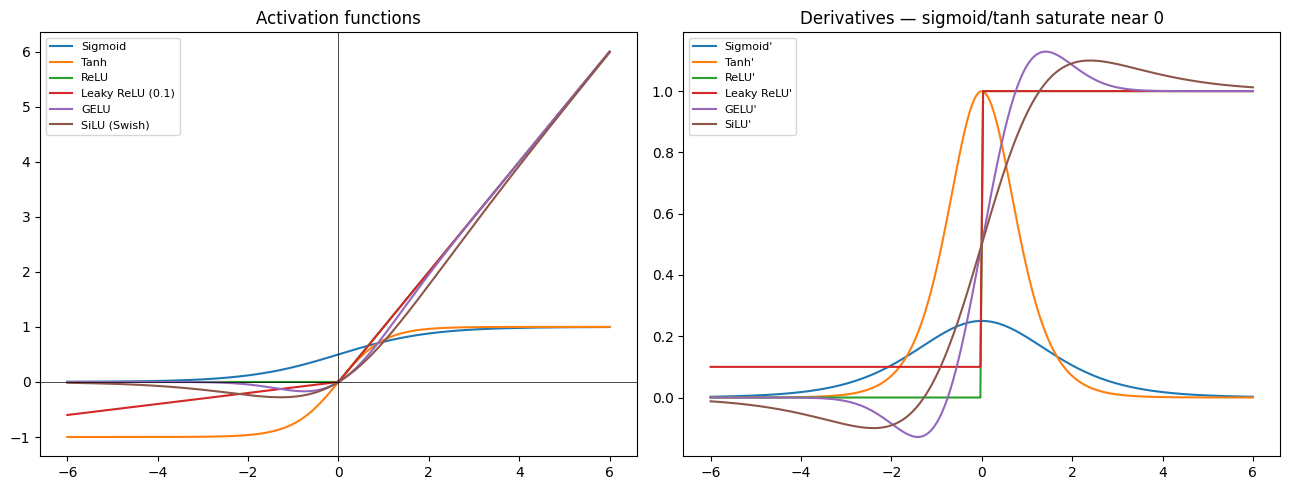

Takeaway: past |x|~3, sigmoid'/tanh' are almost exactly 0 -> almost no gradient signal
reaches earlier layers through a saturated unit. ReLU' is a constant 1 for any x > 0, but
exactly 0 (not just small) for x < 0 -- Leaky ReLU's small non-zero slope there is the fix.


In [2]:
x = torch.linspace(-6, 6, 200)

activations = {
    "Sigmoid": torch.sigmoid(x),
    "Tanh": torch.tanh(x),
    "ReLU": torch.relu(x),
    "Leaky ReLU (0.1)": nn.functional.leaky_relu(x, negative_slope=0.1),
    "GELU": nn.functional.gelu(x),
    "SiLU (Swish)": nn.functional.silu(x),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, y in activations.items():
    axes[0].plot(x, y, label=name)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].axvline(0, color="black", linewidth=0.5)
axes[0].set_title("Activation functions")
axes[0].legend(fontsize=8)


def grad_of(f):
    x_grad = torch.linspace(-6, 6, 200, requires_grad=True)
    y = f(x_grad)
    (g,) = torch.autograd.grad(y, x_grad, grad_outputs=torch.ones_like(y))
    return g.detach()


derivative_fns = {
    "Sigmoid'": torch.sigmoid,
    "Tanh'": torch.tanh,
    "ReLU'": torch.relu,
    "Leaky ReLU'": lambda t: nn.functional.leaky_relu(t, negative_slope=0.1),
    "GELU'": nn.functional.gelu,
    "SiLU'": nn.functional.silu,
}
for name, f in derivative_fns.items():
    axes[1].plot(x, grad_of(f), label=name)
axes[1].set_title("Derivatives — sigmoid/tanh saturate near 0")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Takeaway: past |x|~3, sigmoid'/tanh' are almost exactly 0 -> almost no gradient signal")
print("reaches earlier layers through a saturated unit. ReLU' is a constant 1 for any x > 0, but")
print("exactly 0 (not just small) for x < 0 -- Leaky ReLU's small non-zero slope there is the fix.")


**Softmax is different** — the cheat sheet flags it as "the odd one out," and that's worth seeing
directly rather than taking on faith. Every function above is *pointwise*: it turns one number
into one number, independent of any other input. Softmax turns a whole **vector** of scores into
a probability distribution — change one score, and every output shifts, not just its own. That's
why it can't share the line chart above, and why it lives on output layers / attention (§8)
instead of hidden layers.


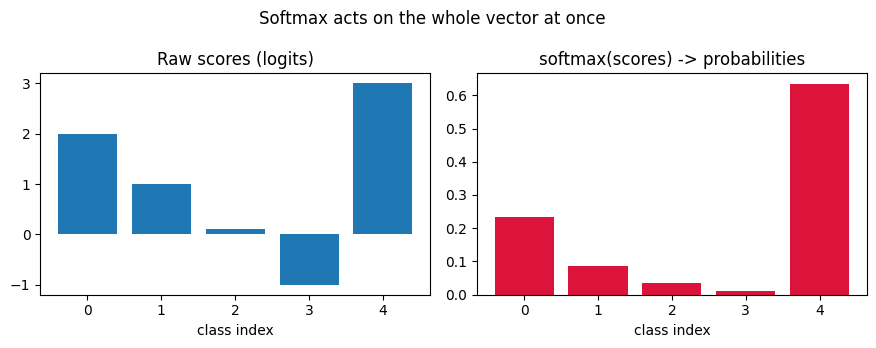

scores: [2.0, 1.0, 0.10000000149011612, -1.0, 3.0]
probs:  [0.233, 0.086, 0.035, 0.012, 0.634] (sum = 1.000)

Takeaway: the largest score (3.0) doesn't just map to 'a high number' in isolation -- its
probability also depends on how large the OTHER scores are. That coupling across the whole
vector is exactly what makes softmax useful for classification and attention weights.


In [3]:
scores = torch.tensor([2.0, 1.0, 0.1, -1.0, 3.0])
probs = torch.softmax(scores, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].bar(range(len(scores)), scores.numpy())
axes[0].set_title("Raw scores (logits)")
axes[0].set_xlabel("class index")
axes[1].bar(range(len(probs)), probs.numpy(), color="crimson")
axes[1].set_title("softmax(scores) -> probabilities")
axes[1].set_xlabel("class index")
plt.suptitle("Softmax acts on the whole vector at once")
plt.tight_layout()
plt.show()

print("scores:", scores.tolist())
print("probs: ", [round(p, 3) for p in probs.tolist()], f"(sum = {probs.sum():.3f})")
print("\nTakeaway: the largest score (3.0) doesn't just map to 'a high number' in isolation -- its")
print("probability also depends on how large the OTHER scores are. That coupling across the whole")
print("vector is exactly what makes softmax useful for classification and attention weights.")


## 3. Foundations — bias–variance trade-off

We fit the *same small-network architecture*, varying only its **width** (number of neurons), to
a noisy sine curve, and look at train vs. test error:

- too few neurons → **underfits** (high bias): can't capture the curve even on training data —
  train and test error are both high, and close together.
- a well-sized network → fits the true signal, generalizes to held-out points — both errors are
  low.
- way too many neurons + long training → **overfits** (high variance): chases the noise — train
  error keeps dropping, but test error doesn't (or gets worse). A widening train/test gap **is**
  the definition of overfitting; the printed numbers below make that gap explicit.


In [4]:
def true_fn(x):
    return np.sin(2 * np.pi * x)


rng = np.random.RandomState(SEED)
x_all = rng.uniform(0, 1, 30)
y_all = true_fn(x_all) + rng.normal(0, 0.2, size=x_all.shape)
x_train_bv, x_test_bv, y_train_bv, y_test_bv = train_test_split(
    x_all, y_all, test_size=0.3, random_state=SEED
)

Xtr_bv = torch.tensor(x_train_bv, dtype=torch.float32).unsqueeze(1)
ytr_bv = torch.tensor(y_train_bv, dtype=torch.float32).unsqueeze(1)
Xte_bv = torch.tensor(x_test_bv, dtype=torch.float32).unsqueeze(1)
yte_bv = torch.tensor(y_test_bv, dtype=torch.float32).unsqueeze(1)


def make_regressor(n_neurons):
    return nn.Sequential(
        nn.Linear(1, n_neurons), nn.Tanh(),
        nn.Linear(n_neurons, n_neurons), nn.Tanh(),
        nn.Linear(n_neurons, 1),
    )


configs = {"Underfit (2 neurons)": 2, "Good fit (16 neurons)": 16, "Overfit (256 neurons)": 256}
results = {}
for name, n in configs.items():
    torch.manual_seed(SEED)
    model = make_regressor(n)
    opt = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()
    for _ in range(12000):  # small/cheap problem, but the 256-neuron net needs this many steps to actually start memorizing noise
        opt.zero_grad()
        loss = loss_fn(model(Xtr_bv), ytr_bv)
        loss.backward()
        opt.step()
    with torch.no_grad():
        train_err = loss_fn(model(Xtr_bv), ytr_bv).item()
        test_err = loss_fn(model(Xte_bv), yte_bv).item()
    results[name] = (model, train_err, test_err)


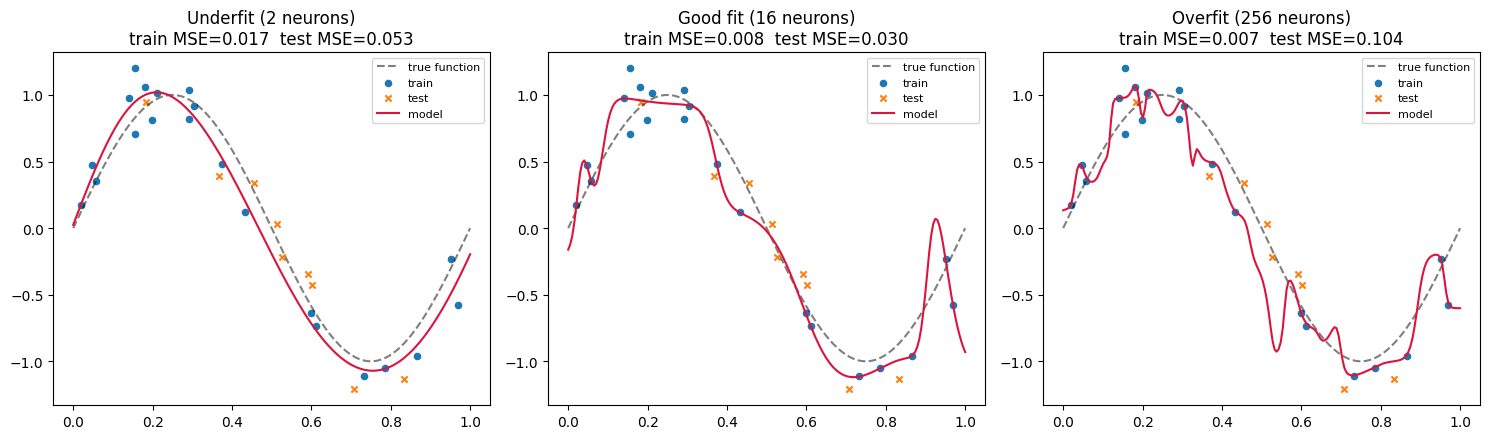

config                  train MSE   test MSE  test-train gap
Underfit (2 neurons)        0.017      0.053          +0.036
Good fit (16 neurons)       0.008      0.030          +0.022
Overfit (256 neurons)       0.007      0.104          +0.097

Takeaway: underfit has both errors high & close; overfit has a low train error but a
large positive gap to test error. The good fit keeps both low AND close.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
x_plot = torch.linspace(0, 1, 200).unsqueeze(1)

for ax, (name, (model, train_err, test_err)) in zip(axes, results.items()):
    with torch.no_grad():
        y_plot = model(x_plot)
    ax.plot(x_plot, true_fn(x_plot.numpy()), "k--", label="true function", alpha=0.5)
    ax.scatter(x_train_bv, y_train_bv, label="train", s=20)
    ax.scatter(x_test_bv, y_test_bv, label="test", s=20, marker="x")
    ax.plot(x_plot, y_plot, color="crimson", label="model")
    ax.set_title(f"{name}\ntrain MSE={train_err:.3f}  test MSE={test_err:.3f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"{'config':22s} {'train MSE':>10s} {'test MSE':>10s} {'test-train gap':>15s}")
for name, (_, train_err, test_err) in results.items():
    print(f"{name:22s} {train_err:10.3f} {test_err:10.3f} {test_err - train_err:+15.3f}")
print("\nTakeaway: underfit has both errors high & close; overfit has a low train error but a")
print("large positive gap to test error. The good fit keeps both low AND close.")


## 4. Foundations — batch vs. online learning

This is about **how a model incorporates data over its lifetime** — a different knob from the
mini-batch size used *inside* a single training run (e.g. `batch_size=64` for efficient gradient
descent, which we use as an optimization detail throughout this notebook and isn't what this
section is about):

- **Batch learning**: periodically retrain a model **from scratch on the full history** of data
  collected so far. Usually very accurate, but the more history accumulates, the more data you
  must store and reprocess every time you retrain.
- **Online learning**: keep a single model and **update it incrementally** using only the newly
  arrived data, without ever revisiting old data or retraining from scratch. Cheap and scalable,
  since cost per update stays constant no matter how much history exists.

To make that concrete, we simulate a stream of data arriving over 6 rounds whose distribution
slowly **drifts** (the two-moons dataset, progressively rotated — think of it as user behavior
gradually shifting). All three models below start identically, trained on round 0's data; a model
left **frozen** after that and never revisited shows what happens if you do neither.


In [6]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=SEED)
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=SEED
)
moons_scaler = StandardScaler().fit(X_moons_train)
X_moons_train_s = moons_scaler.transform(X_moons_train)
X_moons_test_s = moons_scaler.transform(X_moons_test)

Xtr = torch.tensor(X_moons_train_s, dtype=torch.float32)
ytr = torch.tensor(y_moons_train, dtype=torch.float32).unsqueeze(1)
Xte = torch.tensor(X_moons_test_s, dtype=torch.float32)
yte = torch.tensor(y_moons_test, dtype=torch.float32).unsqueeze(1)


class FeedForwardNN(nn.Module):
    def __init__(self, n_hidden_layers, n_neurons):
        super().__init__()
        layers = []
        in_dim = 2
        for _ in range(n_hidden_layers):
            layers += [nn.Linear(in_dim, n_neurons), nn.ReLU()]
            in_dim = n_neurons
        layers += [nn.Linear(in_dim, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def accuracy(model, X, y):
    with torch.no_grad():
        preds = (torch.sigmoid(model(X)) > 0.5).float()
    return (preds == y).float().mean().item()


In [7]:
def make_rotated_moons(angle_deg, n_samples, seed):
    # same two-moons shape every round, just rotated -- a stand-in for real-world data
    # whose patterns gradually shift (e.g. user behavior, prices, sensor drift)
    X, y = make_moons(n_samples=n_samples, noise=0.15, random_state=seed)
    theta = np.deg2rad(angle_deg)
    rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]], dtype=np.float32)
    X_rot = X.astype(np.float32) @ rot.T
    return torch.tensor(X_rot), torch.tensor(y.astype(np.float32)).unsqueeze(1)


def train(model, X, y, epochs, lr=0.05):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
    return model


angles = [0, 15, 30, 45, 60, 75]  # cumulative rotation = how much the data has drifted by that round
stream = [
    (
        *make_rotated_moons(angle, n_samples=250, seed=SEED + i),        # round's new training data
        *make_rotated_moons(angle, n_samples=80, seed=SEED + 100 + i),   # round's held-out test data
    )
    for i, angle in enumerate(angles)
]

torch.manual_seed(SEED)
frozen_model = FeedForwardNN(n_hidden_layers=2, n_neurons=8)
train(frozen_model, stream[0][0], stream[0][1], epochs=300)  # trained once, then never touched again

torch.manual_seed(SEED)
online_model = FeedForwardNN(n_hidden_layers=2, n_neurons=8)
train(online_model, stream[0][0], stream[0][1], epochs=300)  # same starting point as frozen_model

frozen_accs, batch_accs, online_accs = [], [], []
cum_examples, online_examples = [], []
cum_X, cum_y = stream[0][0], stream[0][1]

for t, (X_new, y_new, X_test_t, y_test_t) in enumerate(stream):
    if t == 0:
        batch_model = frozen_model  # round 0: batch and online both start from this same fresh model
    else:
        cum_X, cum_y = torch.cat([cum_X, X_new]), torch.cat([cum_y, y_new])
        torch.manual_seed(SEED)
        batch_model = FeedForwardNN(n_hidden_layers=2, n_neurons=8)
        train(batch_model, cum_X, cum_y, epochs=300)  # retrained from scratch on ALL data seen so far
        train(online_model, X_new, y_new, epochs=30)  # incrementally updated on just the NEW data

    frozen_accs.append(accuracy(frozen_model, X_test_t, y_test_t))
    batch_accs.append(accuracy(batch_model, X_test_t, y_test_t))
    online_accs.append(accuracy(online_model, X_test_t, y_test_t))
    cum_examples.append(len(cum_X))
    online_examples.append(len(X_new))


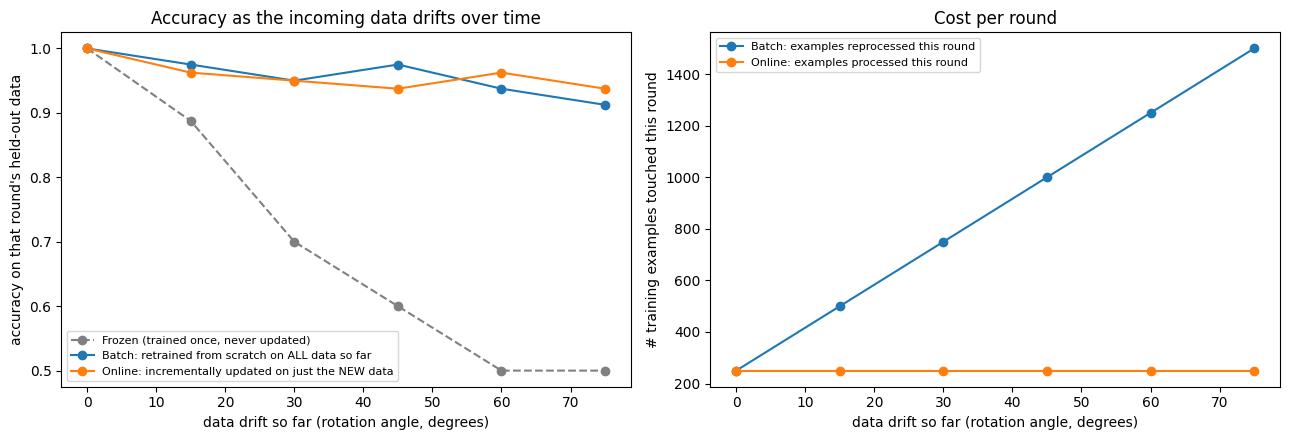

round  angle   frozen    batch   online
    0     0deg  100.0%  100.0%  100.0%
    1    15deg   88.7%   97.5%   96.2%
    2    30deg   70.0%   95.0%   95.0%
    3    45deg   60.0%   97.5%   93.8%
    4    60deg   50.0%   93.8%   96.2%
    5    75deg   50.0%   91.3%   93.8%

Takeaway: the frozen model was fine at round 0, then quietly degrades as the data drifts away
from what it learned -- exactly what happens to a model trained once and never revisited. Both
batch and online learning fix this by incorporating new data, but batch does it by re-touching
EVERY example ever seen (250 -> 1500 examples/round and growing),
while online only ever touches the newest 250 examples -- same outcome,
without needing to store or reprocess history.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(angles, frozen_accs, "o--", color="gray", label="Frozen (trained once, never updated)")
axes[0].plot(angles, batch_accs, "o-", label="Batch: retrained from scratch on ALL data so far")
axes[0].plot(angles, online_accs, "o-", label="Online: incrementally updated on just the NEW data")
axes[0].set_xlabel("data drift so far (rotation angle, degrees)")
axes[0].set_ylabel("accuracy on that round's held-out data")
axes[0].set_title("Accuracy as the incoming data drifts over time")
axes[0].legend(fontsize=8)

axes[1].plot(angles, cum_examples, "o-", label="Batch: examples reprocessed this round")
axes[1].plot(angles, online_examples, "o-", label="Online: examples processed this round")
axes[1].set_xlabel("data drift so far (rotation angle, degrees)")
axes[1].set_ylabel("# training examples touched this round")
axes[1].set_title("Cost per round")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"{'round':>5s} {'angle':>6s} {'frozen':>8s} {'batch':>8s} {'online':>8s}")
for t, a in enumerate(angles):
    print(f"{t:5d} {a:5d}deg {frozen_accs[t]:7.1%} {batch_accs[t]:7.1%} {online_accs[t]:7.1%}")

print("\nTakeaway: the frozen model was fine at round 0, then quietly degrades as the data drifts away")
print("from what it learned -- exactly what happens to a model trained once and never revisited. Both")
print("batch and online learning fix this by incorporating new data, but batch does it by re-touching")
print(f"EVERY example ever seen ({cum_examples[0]} -> {cum_examples[-1]} examples/round and growing),")
print(f"while online only ever touches the newest {online_examples[-1]} examples -- same outcome,")
print("without needing to store or reprocess history.")


## 5. Feedforward NN (FNN/MLP): shallow vs. deep

A **feedforward network** stacks dense layers with non-linear activations; information only flows
forward. We fit a **shallow** net (1 hidden layer) and a **deep** net (4 hidden layers) to the
same non-linearly-separable two-moons dataset used in §4, and compare the decision boundary each
learns — tracking **both train and test accuracy**, so we're not just eyeballing the boundary.


In [9]:
def train_model(model, X, y, epochs=300, lr=0.05):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses


torch.manual_seed(SEED)
shallow = FeedForwardNN(n_hidden_layers=1, n_neurons=4)
losses_shallow = train_model(shallow, Xtr, ytr)

torch.manual_seed(SEED)
deep = FeedForwardNN(n_hidden_layers=4, n_neurons=16)
losses_deep = train_model(deep, Xtr, ytr)

print(f"{'model':8s} {'params':>7s} {'train acc':>10s} {'test acc':>9s}")
for name, model in [("shallow", shallow), ("deep", deep)]:
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{name:8s} {n_params:7d} {accuracy(model, Xtr, ytr):9.1%} {accuracy(model, Xte, yte):9.1%}")


model     params  train acc  test acc
shallow       17     98.0%     99.0%
deep         881     99.3%     95.0%


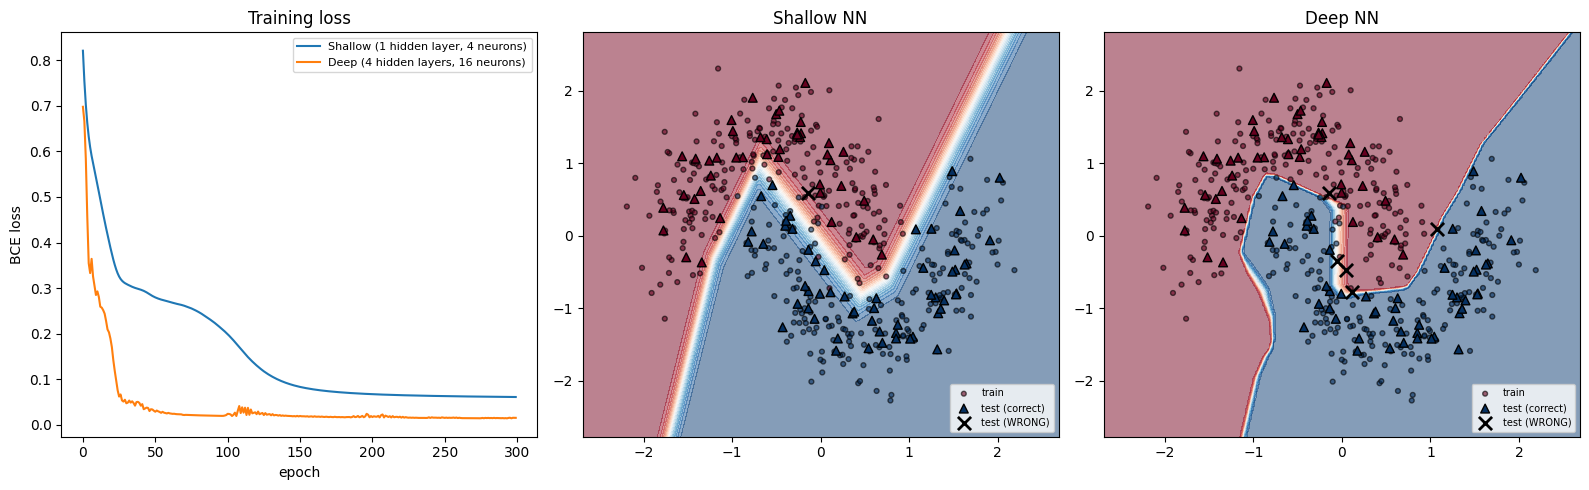

Takeaway: the deep net actually fits the TRAINING data better (higher train accuracy, lower
train loss) yet does WORSE on test data -- classic overfitting, not a fluke. On a small, simple
2D dataset like this, 881 parameters is more capacity than the problem needs, so the deep net's
extra flexibility gets spent chasing individual noisy training points (visible as small wiggles
in its boundary near the black x's) instead of the smooth true pattern. This is the same
bias-variance trade-off from Sec 3, now showing up in a model choice instead of a width sweep --
more depth/capacity only helps once the data actually needs it.


In [10]:
def plot_boundary(ax, model, title):
    x_min, x_max = X_moons_train_s[:, 0].min() - 0.5, X_moons_train_s[:, 0].max() + 0.5
    y_min, y_max = X_moons_train_s[:, 1].min() - 0.5, X_moons_train_s[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        probs = torch.sigmoid(model(grid)).reshape(xx.shape)
        test_preds = (torch.sigmoid(model(Xte)) > 0.5).float().squeeze().numpy()
    ax.contourf(xx, yy, probs, levels=20, cmap="RdBu", alpha=0.5)
    ax.scatter(X_moons_train_s[:, 0], X_moons_train_s[:, 1], c=y_moons_train, cmap="RdBu", edgecolor="k", s=12, alpha=0.6, label="train")
    wrong = test_preds != y_moons_test
    ax.scatter(X_moons_test_s[~wrong, 0], X_moons_test_s[~wrong, 1], c=y_moons_test[~wrong], cmap="RdBu", marker="^", s=40, edgecolor="k", label="test (correct)")
    ax.scatter(X_moons_test_s[wrong, 0], X_moons_test_s[wrong, 1], c="black", marker="x", s=90, linewidths=2, label="test (WRONG)")
    ax.set_title(title)
    ax.legend(fontsize=7, loc="lower right")


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(losses_shallow, label="Shallow (1 hidden layer, 4 neurons)")
axes[0].plot(losses_deep, label="Deep (4 hidden layers, 16 neurons)")
axes[0].set_title("Training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].legend(fontsize=8)

plot_boundary(axes[1], shallow, "Shallow NN")
plot_boundary(axes[2], deep, "Deep NN")
plt.tight_layout()
plt.show()

print("Takeaway: the deep net actually fits the TRAINING data better (higher train accuracy, lower")
print("train loss) yet does WORSE on test data -- classic overfitting, not a fluke. On a small, simple")
print("2D dataset like this, 881 parameters is more capacity than the problem needs, so the deep net's")
print("extra flexibility gets spent chasing individual noisy training points (visible as small wiggles")
print("in its boundary near the black x's) instead of the smooth true pattern. This is the same")
print("bias-variance trade-off from Sec 3, now showing up in a model choice instead of a width sweep --")
print("more depth/capacity only helps once the data actually needs it.")


## 6. Convolutional NN (CNN): filters and feature maps

An MLP on an image has to flatten it into a vector, throwing away the fact that nearby pixels are
related. A CNN instead slides small learned **filters (kernels)** across the image, and — because
the *same* filter is reused at every location — it needs far fewer parameters and detects a
pattern wherever it appears.

We train a tiny CNN and an MLP with a comparable parameter budget on the same task (classifying
8x8 handwritten digit images into 10 classes), then compare them two ways: first by looking
**inside** each model at its first-layer weights side by side, then by testing what that
architectural difference actually buys you in practice — robustness to the image being shifted a
little.

### Terminology, grounded in one real example

Before diving in, here's every term used below, defined against an actual "5" from this dataset
(loaded in the next cell).

| Term | Meaning |
|---|---|
| **Pixel** | One single number in the image. Ranges 0 (blank background) to 16 (darkest ink) in this dataset. When you plot the array, each pixel is drawn as one colored square — "pixel" is the data term, "square" is what it looks like on screen. |
| **Location** | A pixel's (row, column) address, e.g. "location (row=1, col=3)." Just a coordinate. |
| **Image / grid** | The full 8x8 table of pixels: 8 rows x 8 columns = 64 pixels total. It's genuinely 2D — moving along a row or down a column both stay visually adjacent in the original picture. |
| **Flatten** (what the MLP does) | Unroll the 8x8 grid into one list of 64 numbers, row by row. This throws away the grid's geometry: two pixels that were physically neighbors can end up far apart in the flattened list, and the network is never told which numbers used to be adjacent. |
| **Neuron / hidden unit** | A unit that multiplies each of its inputs by its own learned **weight**, sums them (+ a bias), and applies an activation function. |
| **Filter / kernel** | A *small* grid of weights (3x3 = 9 weights here) — a tiny stencil, much smaller than the full image. |
| **Patch / chunk / window / receptive field** | The small group of pixels a filter is looking at right now — e.g. a 3x3 neighborhood. "Receptive field" is the formal name for "the input region one output value depends on." |
| **Sliding / stride** | The filter moves to the next location and repeats; stride = how many pixels it moves each step (stride 1 = shifts by 1 pixel, so patches overlap). |
| **Weight sharing / parameter sharing** | The *same* filter weights are reused at every location the filter visits — not a fresh set of weights per patch. |
| **Feature map** | The result of sliding one filter over the whole image: a new grid where each value says how strongly that filter's pattern matched at that location. |
| **Channels** | A conv layer usually has several filters at once (8, in the code below), each producing its own feature map; the stack of feature maps is described by its channel count. The original grayscale image is "1 channel." |
| **Pooling** | Shrinks a feature map afterward, e.g. take the max of every 2x2 block, turning 8x8 into 4x4 — keeps the strongest signal, discards resolution. |
| **Parameters** | The total count of learnable numbers. This is exactly what weight sharing minimizes: one 3x3 filter is 9 parameters no matter how many locations it's applied to, versus an MLP hidden unit's 64 independent weights (one per pixel, never reused). |


A real '5' from this dataset, exactly as the network sees it -- 8 rows x 8 columns, 64 pixels,
each one a single number from 0 (blank background) to 16 (darkest ink):

[[ 0  0 12 10  0  0  0  0]
 [ 0  0 14 16 16 14  0  0]
 [ 0  0 13 16 15 10  1  0]
 [ 0  0 11 16 16  7  0  0]
 [ 0  0  0  4  7 16  7  0]
 [ 0  0  0  0  4 16  9  0]
 [ 0  0  5  4 12 16  4  0]
 [ 0  0  9 16 16 10  0  0]]

One 3x3 patch a filter centered at location (row=1, col=3) would see -- just 9 of the 64 numbers:

[[12 10  0]
 [14 16 16]
 [13 16 15]]


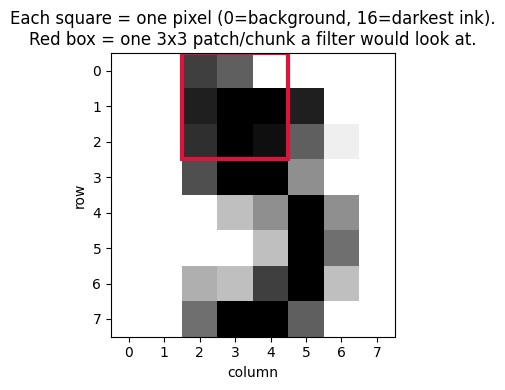


Takeaway: a filter centered here never sees the '0' pixels in the corners or the tail of the 5
at the bottom -- only these 9 numbers. To 'see' the whole image, the SAME filter slides to every
other location too, one patch at a time.


In [11]:
illustration_digits = load_digits()
five_idx = np.where(illustration_digits.target == 5)[0][0]
five_image = illustration_digits.images[five_idx].astype(int)

print("A real '5' from this dataset, exactly as the network sees it -- 8 rows x 8 columns, 64 pixels,")
print("each one a single number from 0 (blank background) to 16 (darkest ink):\n")
print(five_image)

patch = five_image[0:3, 2:5]
print("\nOne 3x3 patch a filter centered at location (row=1, col=3) would see -- just 9 of the 64 numbers:\n")
print(patch)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(five_image, cmap="gray_r", vmin=0, vmax=16)
ax.add_patch(plt.Rectangle((1.5, -0.5), 3, 3, edgecolor="crimson", facecolor="none", linewidth=3))
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.set_xlabel("column")
ax.set_ylabel("row")
ax.set_title("Each square = one pixel (0=background, 16=darkest ink).\nRed box = one 3x3 patch/chunk a filter would look at.")
plt.tight_layout()
plt.show()

print("\nTakeaway: a filter centered here never sees the '0' pixels in the corners or the tail of the 5")
print("at the bottom -- only these 9 numbers. To 'see' the whole image, the SAME filter slides to every")
print("other location too, one patch at a time.")


In [12]:
digits = load_digits()
X_dig = digits.data.astype(np.float32) / 16.0  # scale pixel values to [0, 1]
y_dig = digits.target

X_dig_train, X_dig_test, y_dig_train, y_dig_test = train_test_split(
    X_dig, y_dig, test_size=0.2, random_state=SEED, stratify=y_dig
)
Xdig_tr = torch.tensor(X_dig_train)
Xdig_te = torch.tensor(X_dig_test)
ydig_tr = torch.tensor(y_dig_train, dtype=torch.long)
ydig_te = torch.tensor(y_dig_test, dtype=torch.long)

Xdig_tr_img = Xdig_tr.view(-1, 1, 8, 8)
Xdig_te_img = Xdig_te.view(-1, 1, 8, 8)


class SimpleCNN(nn.Module):
    def __init__(self, n_filters1=8, n_filters2=16):
        super().__init__()
        self.conv1 = nn.Conv2d(1, n_filters1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_filters1, n_filters2, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(n_filters2 * 2 * 2, 10)

    def forward(self, x):
        f1 = self.pool(torch.relu(self.conv1(x)))  # 8x8 -> 4x4
        f2 = self.pool(torch.relu(self.conv2(f1)))  # 4x4 -> 2x2
        return self.fc(f2.flatten(1))

    def feature_maps(self, x):
        f1 = torch.relu(self.conv1(x))
        return f1


class SimpleMLP(nn.Module):
    def __init__(self, hidden=24):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(64, hidden), nn.ReLU(), nn.Linear(hidden, 10))

    def forward(self, x):
        return self.net(x.flatten(1))


def train_classifier(model, X, y, epochs=200, lr=0.01):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
    return model


def clf_accuracy(model, X, y):
    with torch.no_grad():
        preds = model(X).argmax(1)
    return (preds == y).float().mean().item()


torch.manual_seed(SEED)
cnn = train_classifier(SimpleCNN(), Xdig_tr_img, ydig_tr)
torch.manual_seed(SEED)
mlp = train_classifier(SimpleMLP(), Xdig_tr_img, ydig_tr)

print(f"CNN: {sum(p.numel() for p in cnn.parameters())} params, test acc = {clf_accuracy(cnn, Xdig_te_img, ydig_te):.1%}")
print(f"MLP: {sum(p.numel() for p in mlp.parameters())} params, test acc = {clf_accuracy(mlp, Xdig_te_img, ydig_te):.1%}")


CNN: 1898 params, test acc = 97.5%
MLP: 1810 params, test acc = 96.4%


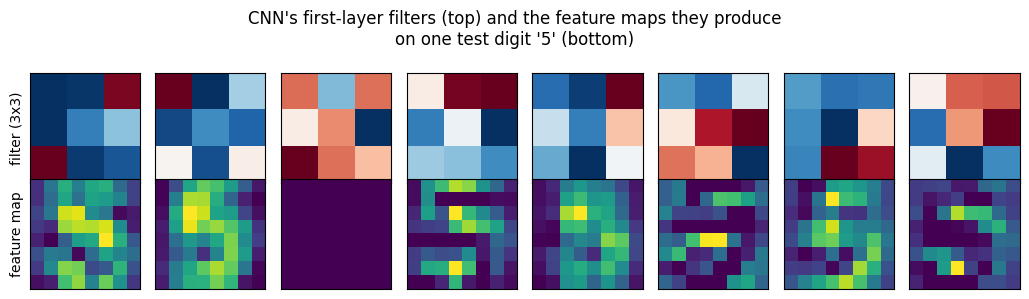

Takeaway: each filter reacts differently to the same input image — some fire on strokes
in one orientation, some on curves — that's the CNN building reusable local detectors
instead of the MLP's one-giant-weight-per-pixel approach.


In [13]:
with torch.no_grad():
    filters = cnn.conv1.weight[:, 0].numpy()  # (n_filters1, 3, 3)
    sample_img = Xdig_te_img[0:1]
    feature_maps = cnn.feature_maps(sample_img)[0].numpy()  # (n_filters1, 8, 8)

n_filters = filters.shape[0]
fig, axes = plt.subplots(2, n_filters, figsize=(1.3 * n_filters, 3))

for i in range(n_filters):
    axes[0, i].imshow(filters[i], cmap="RdBu")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    axes[1, i].imshow(feature_maps[i], cmap="viridis")
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
axes[0, 0].set_ylabel("filter (3x3)")
axes[1, 0].set_ylabel("feature map")
plt.suptitle(f"CNN's first-layer filters (top) and the feature maps they produce\non one test digit '{y_dig_test[0]}' (bottom)")
plt.tight_layout()
plt.show()

print("Takeaway: each filter reacts differently to the same input image — some fire on strokes")
print("in one orientation, some on curves — that's the CNN building reusable local detectors")
print("instead of the MLP's one-giant-weight-per-pixel approach.")


**Now the direct comparison.** The CNN's first layer is 8 filters, 3x3 = 9 numbers each, reused
at every position in the image. The MLP's first layer is a set of hidden units that each see the
*entire* flattened image at once — so each one owns a full 64-number weight vector, which we can
reshape back into an 8x8 image to look at exactly like a filter. Same idea (learned weights that
respond to the input), very different shape.


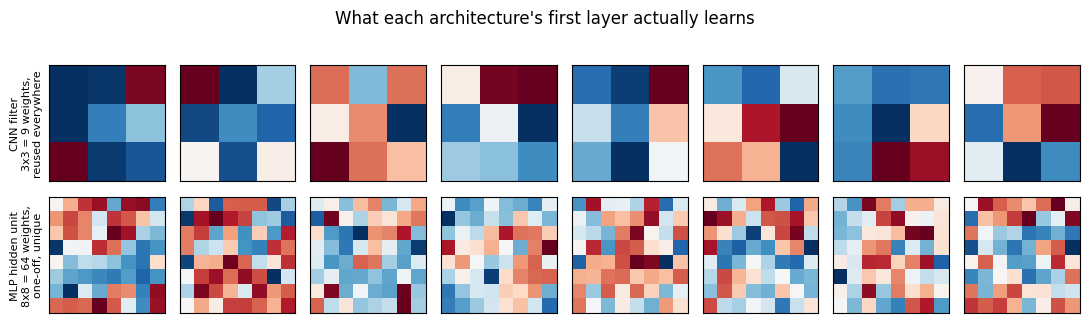

Takeaway: the CNN's 9-number filters are small enough to visually interpret and get applied
everywhere in the image. Each MLP hidden unit instead carries a full, diffuse 64-number image
of its own -- there's no reuse, and no built-in notion that nearby pixels are related.


In [14]:
with torch.no_grad():
    cnn_filters = cnn.conv1.weight[:, 0].numpy()  # (8, 3, 3) -- reused at every location
    mlp_filters = mlp.net[0].weight[:8].reshape(-1, 8, 8).numpy()  # first 8 of 24 hidden units, unrolled back to an image

fig, axes = plt.subplots(2, 8, figsize=(11, 3.4))
for i in range(8):
    axes[0, i].imshow(cnn_filters[i], cmap="RdBu")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    axes[1, i].imshow(mlp_filters[i], cmap="RdBu")
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
axes[0, 0].set_ylabel("CNN filter\n3x3 = 9 weights,\nreused everywhere", fontsize=8)
axes[1, 0].set_ylabel("MLP hidden unit\n8x8 = 64 weights,\none-off, unique", fontsize=8)
plt.suptitle("What each architecture's first layer actually learns")
plt.tight_layout()
plt.show()

print("Takeaway: the CNN's 9-number filters are small enough to visually interpret and get applied")
print("everywhere in the image. Each MLP hidden unit instead carries a full, diffuse 64-number image")
print("of its own -- there's no reuse, and no built-in notion that nearby pixels are related.")


**Does that difference matter in practice?** We test it directly: shift every test image by 1
pixel (something neither model was trained on) and see how much accuracy each one loses. If the
CNN's local, reused filters generalize better to "the same stroke, slightly moved," it should hold
up better than the MLP, whose weights are tied to exact pixel positions.


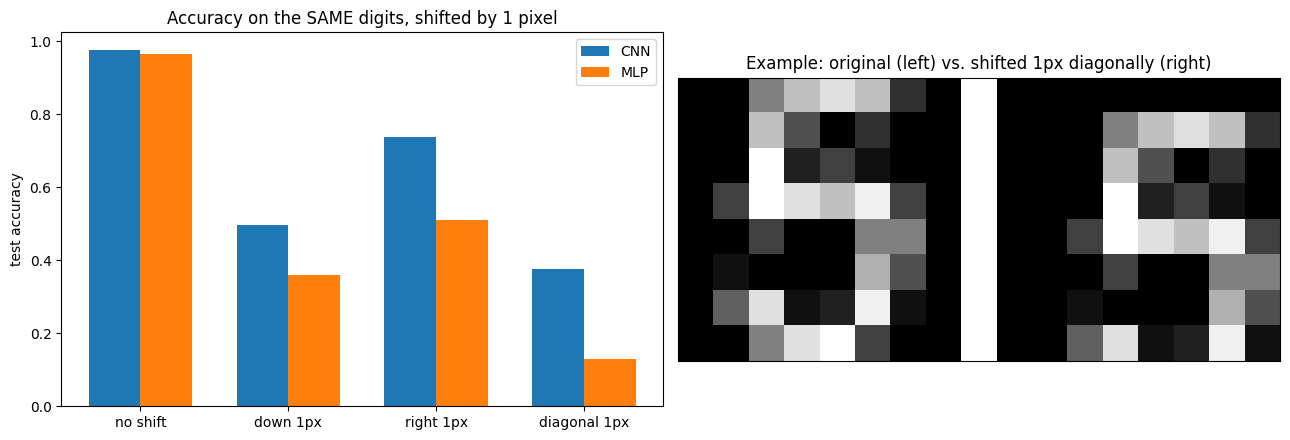

no shift       CNN=97.5%  MLP=96.4%
down 1px       CNN=49.7%  MLP=35.8%
right 1px      CNN=73.6%  MLP=51.1%
diagonal 1px   CNN=37.5%  MLP=13.1%

Takeaway: an 8x8 image makes a 1-pixel shift a big relative change, so both models take a real
hit -- but the CNN consistently keeps more of its accuracy than the MLP in every direction tested.
Its filters still recognize a stroke wherever it lands; the MLP had learned exactly which of its
64 fixed pixel positions to look at, and a shift breaks that alignment.


In [15]:
def shift_images(imgs, dy, dx):
    # shift by (dy, dx) pixels, filling the newly-exposed edge with 0 (no wraparound)
    shifted = torch.zeros_like(imgs)
    H, W = imgs.shape[-2], imgs.shape[-1]
    src_y0, src_y1 = max(0, -dy), min(H, H - dy)
    src_x0, src_x1 = max(0, -dx), min(W, W - dx)
    dst_y0, dst_y1 = max(0, dy), min(H, H + dy)
    dst_x0, dst_x1 = max(0, dx), min(W, W + dx)
    shifted[:, :, dst_y0:dst_y1, dst_x0:dst_x1] = imgs[:, :, src_y0:src_y1, src_x0:src_x1]
    return shifted


shifts = {"no shift": (0, 0), "down 1px": (1, 0), "right 1px": (0, 1), "diagonal 1px": (1, 1)}
cnn_accs = [clf_accuracy(cnn, shift_images(Xdig_te_img, dy, dx), ydig_te) for dy, dx in shifts.values()]
mlp_accs = [clf_accuracy(mlp, shift_images(Xdig_te_img, dy, dx), ydig_te) for dy, dx in shifts.values()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x_pos = np.arange(len(shifts))
width = 0.35
axes[0].bar(x_pos - width / 2, cnn_accs, width, label="CNN")
axes[0].bar(x_pos + width / 2, mlp_accs, width, label="MLP")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(shifts.keys())
axes[0].set_ylabel("test accuracy")
axes[0].set_title("Accuracy on the SAME digits, shifted by 1 pixel")
axes[0].legend()

example = Xdig_te_img[0, 0].numpy()
example_shifted = shift_images(Xdig_te_img[0:1], 1, 1)[0, 0].numpy()
axes[1].imshow(np.concatenate([example, np.ones((8, 1)), example_shifted], axis=1), cmap="gray")
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].set_title("Example: original (left) vs. shifted 1px diagonally (right)")

plt.tight_layout()
plt.show()

for name, c, m in zip(shifts.keys(), cnn_accs, mlp_accs):
    print(f"{name:14s} CNN={c:.1%}  MLP={m:.1%}")

print("\nTakeaway: an 8x8 image makes a 1-pixel shift a big relative change, so both models take a real")
print("hit -- but the CNN consistently keeps more of its accuracy than the MLP in every direction tested.")
print("Its filters still recognize a stroke wherever it lands; the MLP had learned exactly which of its")
print("64 fixed pixel positions to look at, and a shift breaks that alignment.")


## 7. Recurrent NNs: why gating (LSTM/GRU) beats vanilla RNN

RNNs keep a hidden state that's updated at every time step. Section 6 showed a CNN's key trick is
**weight sharing across space**: the same small filter, reused at every location, so it detects a
pattern wherever it appears. RNNs (and LSTM/GRU) do the analogous thing **across time**: the same
small step function, reused at every time step, so it can act on a pattern whenever it occurs in
a sequence -- no matter how long the sequence is or where in it the pattern shows up.

### Why the earlier task didn't actually test that

The long-range-recall task used earlier planted its signal at the exact same position (3) in
*every* sequence. That let a plain MLP cheat: it could dedicate one large, fixed weight to input
feature #3 and ignore the rest -- solving the task without doing anything sequence-like at all,
which is why it also won that comparison. That's a fair thing to notice, but it means the task
never actually required weight sharing across time, so it couldn't showcase what gating is *for*.

**This section fixes that.** The signal can now appear at a *different, random* position in every
sequence, marked by a distinctive "flag" value (2.0, outside the normal +/-1 input range) -- the
model has to find the flag wherever it happens to be, then remember whatever comes right after it.
No fixed input index is informative anymore, so a model that only knows how to look at fixed
positions (an MLP) is structurally out of luck: it would need separate, dedicated weights for
"detect the flag *if* it's at position 0," "...if it's at position 1," and so on for every
possible position -- no reuse, no sharing. A model that applies the *same* small rule at every
position (RNN family) only has to learn that rule once.


In [16]:
def make_flagged_dataset(seq_len=30, n_samples=1500, flag_value=2.0, min_pos=0, max_pos=20):
    # the flag can land anywhere from min_pos to max_pos -- a different position each sequence.
    # whatever immediately follows the flag is the value to remember and output at the very end.
    rng = np.random.RandomState(SEED)
    X = rng.uniform(-1, 1, size=(n_samples, seq_len)).astype(np.float32)
    positions = rng.randint(min_pos, max_pos + 1, size=n_samples)
    y = np.zeros(n_samples, dtype=np.float32)
    for i, p in enumerate(positions):
        X[i, p] = flag_value
        signal = rng.uniform(-1, 1)
        X[i, p + 1] = signal
        y[i] = signal
    return torch.tensor(X).unsqueeze(-1), torch.tensor(y).unsqueeze(-1), positions


X_seq, y_seq, flag_positions = make_flagged_dataset()
n_train = 1200
X_seq_train, y_seq_train = X_seq[:n_train], y_seq[:n_train]
X_seq_test, y_seq_test = X_seq[n_train:], y_seq[n_train:]
pos_train, pos_test = flag_positions[:n_train], flag_positions[n_train:]
X_seq_train_flat, X_seq_test_flat = X_seq_train.squeeze(-1), X_seq_test.squeeze(-1)

baseline_mse = (y_seq_test ** 2).mean().item()
print("One example sequence (flag=2.0 marks where the value-to-remember starts):")
print(np.round(X_seq_test_flat[0].numpy(), 2))
print(f"-> target = {y_seq_test[0].item():.3f}  (the value right after the flag, at position {pos_test[0] + 1})")
print(f"\nbaseline MSE ('always predict 0'): {baseline_mse:.4f}")


One example sequence (flag=2.0 marks where the value-to-remember starts):
[ 0.83  0.9  -0.99 -0.37  0.67  0.07  0.62  0.71 -0.11  2.    0.36  0.31
 -0.27  0.55  0.81 -0.44  0.93  0.25  0.76 -0.79 -0.5  -0.36 -0.39 -0.66
  0.74 -0.16  0.93  0.17 -0.72  0.09]
-> target = 0.359  (the value right after the flag, at position 10)

baseline MSE ('always predict 0'): 0.3058


### MLP: does it manage anyway?

An MLP still technically *could* solve this in principle (enough hidden units can approximate
almost anything) -- but with a hidden layer the same modest size as the RNNs below (32 units, no
special advantage), it has nowhere near enough dedicated per-position capacity to learn a
separate flag-detector for every one of the ~20 possible positions. Let's just check.


In [17]:
mlp_seq = nn.Sequential(nn.Linear(30, 32), nn.ReLU(), nn.Linear(32, 1))
opt = optim.Adam(mlp_seq.parameters(), lr=0.005)
loss_fn = nn.MSELoss()

torch.manual_seed(SEED)
n = len(X_seq_train_flat)
mlp_train_losses, mlp_test_losses = [], []
for _ in range(800):  # same epoch budget as the recurrent models below, for a fair comparison
    perm = torch.randperm(n)
    epoch_losses = []
    for i in range(0, n, 64):
        idx = perm[i : i + 64]
        opt.zero_grad()
        loss = loss_fn(mlp_seq(X_seq_train_flat[idx]), y_seq_train[idx])
        loss.backward()
        opt.step()
        epoch_losses.append(loss.item())
    mlp_train_losses.append(np.mean(epoch_losses))
    with torch.no_grad():
        mlp_test_losses.append(loss_fn(mlp_seq(X_seq_test_flat), y_seq_test).item())

mlp_test_mse = mlp_test_losses[-1]
print(f"MLP test MSE: {mlp_test_mse:.4f}  (baseline was {baseline_mse:.4f})")
print("\nTakeaway: with the flag position varying per example, the MLP's old trick -- one big weight")
print("on a fixed input index -- no longer applies. It comes out at or worse than the 'guess nothing'")
print("baseline: 800 epochs of training and it still hasn't found a position-independent rule, because")
print("nothing in its architecture lets a rule learned for one position transfer to another.")


MLP test MSE: 0.6468  (baseline was 0.3058)

Takeaway: with the flag position varying per example, the MLP's old trick -- one big weight
on a fixed input index -- no longer applies. It comes out at or worse than the 'guess nothing'
baseline: 800 epochs of training and it still hasn't found a position-independent rule, because
nothing in its architecture lets a rule learned for one position transfer to another.


### Why does gating actually help here, mechanically?

The task now needs three things, all harder than before: (1) recognize the flag *wherever it
occurs* and note that the *next* value is the one that matters, (2) protect that value through
however many noise steps remain until the end (a different number every time), (3) read it back
out. Step (1) is where weight sharing across time comes in -- the RNN family's step function is
identical at every position, so a rule for "is my current input close to 2.0?" learned from
training sequences with the flag at position 5 applies just as well when the flag shows up at
position 15. Step (2) is where the RNN/LSTM/GRU split we already know about kicks back in.

**Vanilla RNN** has one hidden state, updated the same way at every step:
`h_t = tanh(W_hh @ h_{t-1} + W_xh @ x_t + b)`. There's no way to "skip" a step -- every noise input
gets mixed into the state through the same nonlinear transform. To preserve the signal, `W_hh` and
`W_xh` would need to combine into something very close to an *exact* identity map, held stable for
however many steps remain -- and since that remaining distance now varies (anywhere from a handful
of steps to nearly 30), there's no single fixed trick to lean on. That's a narrow target for
gradient descent to find at all, let alone one that generalizes across every possible remaining
distance.

**LSTM** adds a second, separate memory: the *cell state* `c_t`, updated **additively**:
`c_t = f_t * c_{t-1} + i_t * g_t`. The forget gate `f_t` and input gate `i_t` are themselves small
learned sigmoid networks (outputs between 0 and 1). Once the flag has been seen, the model can
learn `f_t ~= 1` (keep everything) and `i_t ~= 0` (ignore further noise), making `c_t ~= c_{t-1}` --
an almost-exact hold that works the same way regardless of how many steps are left. Landing a
sigmoid near 0 or 1 is a far easier, more stable target for gradient descent than the vanilla
RNN's exact-identity requirement, and gradients flowing back through that near-identity path
don't get squashed by a fresh `tanh` at every step.

**GRU** does the same trick with one gate instead of two: an update gate `z_t` learned close to 0
on noise steps makes `h_t ~= h_{t-1}` -- hold the state, don't touch it, no matter how long "the
rest of the sequence" turns out to be.

None of this is hard-coded -- it's *learned*, purely because it reduces the loss. Gating just makes
"hold my memory steady, for as long as it takes" an easy, stable, *general* solution to land on;
the vanilla RNN's architecture makes that same solution hard to reach and unstable to generalize.

> This cell trains 3 models for 800 epochs each with mini-batch gradient descent -- it takes
> **~4-6 minutes** on CPU, the slowest cell in this notebook.


In [18]:
class SequenceModel(nn.Module):
    def __init__(self, cell_type="RNN", hidden_size=32):
        super().__init__()
        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[cell_type]
        self.rnn = rnn_cls(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])  # prediction from the last time step


def train_sequence_model(cell_type, epochs=800, lr=0.005, batch_size=64, clip=1.0):
    torch.manual_seed(SEED)
    model = SequenceModel(cell_type)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    n = len(X_seq_train)
    losses, test_losses, grad_norms = [], [], []
    for _ in range(epochs):
        perm = torch.randperm(n)
        epoch_losses, epoch_grad_norms = [], []
        for i in range(0, n, batch_size):
            idx = perm[i : i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X_seq_train[idx]), y_seq_train[idx])
            loss.backward()
            # clip_grad_norm_ returns the RAW norm (pre-clipping) as a side effect -- free to record
            raw_norm = nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            epoch_losses.append(loss.item())
            epoch_grad_norms.append(raw_norm.item())
        losses.append(np.mean(epoch_losses))
        grad_norms.append(np.max(epoch_grad_norms))
        with torch.no_grad():
            test_losses.append(loss_fn(model(X_seq_test), y_seq_test).item())  # cheap: one extra forward pass/epoch
    return model, losses, test_losses, grad_norms


CLIP_THRESHOLD = 1.0
models_seq, losses_seq, test_losses_seq, grad_norms_seq = {}, {}, {}, {}
for cell in ["RNN", "LSTM", "GRU"]:
    models_seq[cell], losses_seq[cell], test_losses_seq[cell], grad_norms_seq[cell] = train_sequence_model(cell, clip=CLIP_THRESHOLD)

# sanity check: is any test sequence actually a duplicate of a training sequence? (it shouldn't be --
# each was independently sampled -- but worth verifying rather than assuming)
train_rows = set(map(tuple, X_seq_train.squeeze(-1).numpy().round(6).tolist()))
n_overlap = sum(1 for row in X_seq_test.squeeze(-1).numpy().round(6).tolist() if tuple(row) in train_rows)
print(f"Leakage check: {n_overlap} / {len(X_seq_test)} test sequences duplicate a training sequence (expect 0)")

train_mses = {"MLP": mlp_train_losses[-1]}
test_mses = {"MLP": mlp_test_mse}
for cell, model in models_seq.items():
    train_mses[cell] = losses_seq[cell][-1]
    with torch.no_grad():
        test_mses[cell] = nn.functional.mse_loss(model(X_seq_test), y_seq_test).item()

print(f"\n{'model':6s} {'train MSE':>10s} {'test MSE':>10s} {'gap':>9s}")
print(f"{'base':6s} {'':>10s} {baseline_mse:10.4f}   <- 'always predict 0'")
for name in ["MLP", "RNN", "LSTM", "GRU"]:
    print(f"{name:6s} {train_mses[name]:10.6f} {test_mses[name]:10.6f} {test_mses[name]-train_mses[name]:+9.6f}")

print("\nRanked best to worst (test MSE):")
for rank, (name, mse) in enumerate(sorted(test_mses.items(), key=lambda kv: kv[1]), start=1):
    print(f"  {rank}. {name:5s} {mse:.6f}")

print("\nOn 'suspiciously good' test performance: LSTM/GRU's train and test MSE are BOTH near zero, with")
print("almost no gap between them -- that's the opposite signature of memorization (which would show a")
print("low train / high test gap, like MLP and RNN do above). Once the general rule is learned, this task")
print("has no ambiguity left to exploit: the flag (2.0) can never be confused with noise in [-1, 1], so a")
print("model that's found the rule really should generalize almost perfectly to any new flag position.")


Leakage check: 0 / 300 test sequences duplicate a training sequence (expect 0)

model   train MSE   test MSE       gap
base                  0.3058   <- 'always predict 0'
MLP      0.014733   0.646767 +0.632034
RNN      0.083457   0.484263 +0.400807
LSTM     0.000040   0.000070 +0.000031
GRU      0.000003   0.000004 +0.000001

Ranked best to worst (test MSE):
  1. GRU   0.000004
  2. LSTM  0.000070
  3. RNN   0.484263
  4. MLP   0.646767

On 'suspiciously good' test performance: LSTM/GRU's train and test MSE are BOTH near zero, with
almost no gap between them -- that's the opposite signature of memorization (which would show a
low train / high test gap, like MLP and RNN do above). Once the general rule is learned, this task
has no ambiguity left to exploit: the flag (2.0) can never be confused with noise in [-1, 1], so a
model that's found the rule really should generalize almost perfectly to any new flag position.


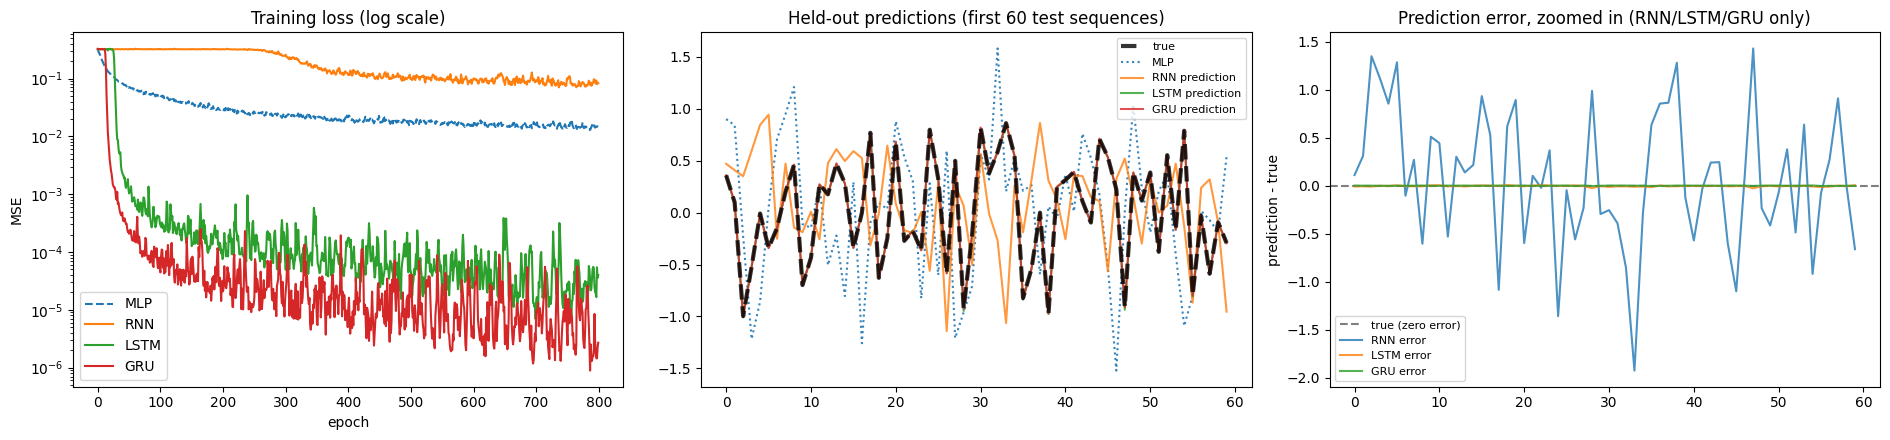

Takeaway: MLP and vanilla RNN both land at or worse than the baseline -- neither found a
position-independent rule. LSTM and GRU both solve it almost perfectly, several orders of
magnitude better, using the exact same weight-sharing-across-time property that let a CNN
filter (Sec 6) recognize a stroke wherever it appeared in an image. Their predictions overlap
the true (dashed) line so closely in the middle panel that it's genuinely hard to see -- that's
not a plotting bug, it's what a test MSE of ~0.00001-0.0001 actually looks like. The right panel
zooms into just the error to make it visible: still not exactly zero, just small and unbiased --
consistent with genuine generalization, not memorization.


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))

axes[0].plot(mlp_train_losses, label="MLP", linestyle="--")
for cell, l in losses_seq.items():
    axes[0].plot(l, label=cell)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")
axes[0].set_title("Training loss (log scale)")
axes[0].legend()

# true values plotted thick + on top (zorder), since LSTM/GRU's predictions overlap it almost exactly
axes[1].plot(y_seq_test[:60].numpy().ravel(), "k--", label="true", linewidth=3, zorder=10, alpha=0.8)
with torch.no_grad():
    axes[1].plot(mlp_seq(X_seq_test_flat[:60]).numpy().ravel(), label="MLP", linestyle=":", alpha=0.9)
    for cell, m in models_seq.items():
        axes[1].plot(m(X_seq_test[:60]).numpy().ravel(), label=f"{cell} prediction", alpha=0.8)
axes[1].set_title("Held-out predictions (first 60 test sequences)")
axes[1].legend(fontsize=8)

# zoomed-in view of prediction ERROR (residual), since LSTM/GRU's residuals are too small to see above
axes[2].axhline(0, color="black", linestyle="--", alpha=0.5, label="true (zero error)")
with torch.no_grad():
    for cell, m in models_seq.items():
        residual = (m(X_seq_test[:60]) - y_seq_test[:60]).numpy().ravel()
        axes[2].plot(residual, label=f"{cell} error", alpha=0.8)
axes[2].set_title("Prediction error, zoomed in (RNN/LSTM/GRU only)")
axes[2].set_ylabel("prediction - true")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Takeaway: MLP and vanilla RNN both land at or worse than the baseline -- neither found a")
print("position-independent rule. LSTM and GRU both solve it almost perfectly, several orders of")
print("magnitude better, using the exact same weight-sharing-across-time property that let a CNN")
print("filter (Sec 6) recognize a stroke wherever it appeared in an image. Their predictions overlap")
print("the true (dashed) line so closely in the middle panel that it's genuinely hard to see -- that's")
print("not a plotting bug, it's what a test MSE of ~0.00001-0.0001 actually looks like. The right panel")
print("zooms into just the error to make it visible: still not exactly zero, just small and unbiased --")
print("consistent with genuine generalization, not memorization.")


### What actually goes wrong for vanilla RNN here

Rather than the single dramatic gradient explosion seen on the fixed-position task, this harder
version produces a different, equally telling failure: check the gap between RNN's *training*
loss and its *test* loss.


RNN train MSE: 0.0835
RNN test MSE:  0.4843
gap: +0.4008

median raw gradient norm during training: 2.25  (clip threshold: 1.0)
max raw gradient norm seen: 22.5 at epoch 450


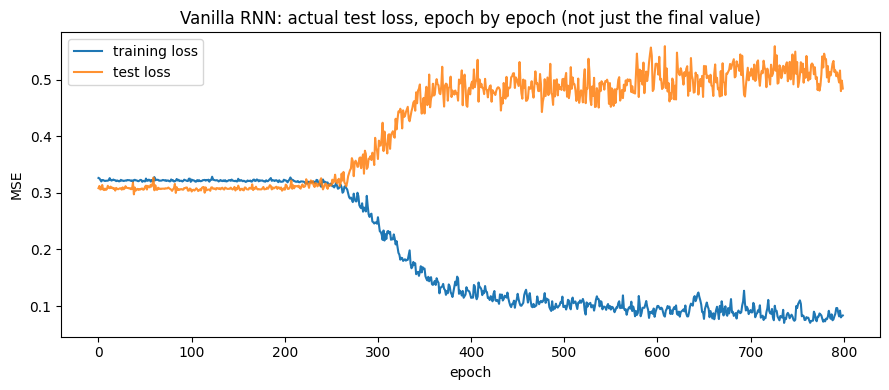


Both curves start together near baseline (~epoch 0: train=0.326, test=0.308).
Train loss starts actually dropping around epoch 291; from there test loss doesn't
just stay flat -- it gets WORSE, peaking at 0.559 around epoch 608,
before settling around 0.513.

Takeaway: this is the bias-variance story from Sec 3 and Sec 5, back again in a new costume.
The moment RNN starts fitting the 1200 specific training sequences more closely -- memorizing
which flag positions happened to appear and what followed them, rather than discovering the
GENERAL rule 'find the flag, hold what follows' -- is the exact moment test loss turns around and
gets WORSE, not just flat. That's the overfitting inflection point, directly visible. Gradient
norms here spike above the clip threshold repeatedly rather than in one dramatic single event --
chronic instability, not one catastrophic hit, but the same underlying cause: repeatedly
multiplying a hidden state through the same recurrent weights and a saturating ta

In [20]:
rnn_train_mse = losses_seq["RNN"][-1]
rnn_test_mse = test_losses_seq["RNN"][-1]
rnn_norms = np.array(grad_norms_seq["RNN"])

print(f"RNN train MSE: {rnn_train_mse:.4f}")
print(f"RNN test MSE:  {rnn_test_mse:.4f}")
print(f"gap: {rnn_test_mse - rnn_train_mse:+.4f}")
print(f"\nmedian raw gradient norm during training: {np.median(rnn_norms):.2f}  (clip threshold: {CLIP_THRESHOLD})")
print(f"max raw gradient norm seen: {rnn_norms.max():.1f} at epoch {int(rnn_norms.argmax())}")

# actual per-epoch test loss, not just the final value -- so we can see its real trajectory,
# not assume it from a single endpoint
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(losses_seq["RNN"], label="training loss")
ax.plot(test_losses_seq["RNN"], label="test loss", alpha=0.85)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.set_title("Vanilla RNN: actual test loss, epoch by epoch (not just the final value)")
ax.legend()
plt.tight_layout()
plt.show()

rnn_test_arr = np.array(test_losses_seq["RNN"])
rnn_train_arr = np.array(losses_seq["RNN"])
diverge_epoch = int(np.where(rnn_train_arr < rnn_train_arr[0] * 0.8)[0][0])  # first real drop in train loss
peak_epoch = int(rnn_test_arr.argmax())

print(f"\nBoth curves start together near baseline (~epoch 0: train={rnn_train_arr[0]:.3f}, test={rnn_test_arr[0]:.3f}).")
print(f"Train loss starts actually dropping around epoch {diverge_epoch}; from there test loss doesn't")
print(f"just stay flat -- it gets WORSE, peaking at {rnn_test_arr[peak_epoch]:.3f} around epoch {peak_epoch},")
print(f"before settling around {rnn_test_arr[-100:].mean():.3f}.")
print("\nTakeaway: this is the bias-variance story from Sec 3 and Sec 5, back again in a new costume.")
print("The moment RNN starts fitting the 1200 specific training sequences more closely -- memorizing")
print("which flag positions happened to appear and what followed them, rather than discovering the")
print("GENERAL rule 'find the flag, hold what follows' -- is the exact moment test loss turns around and")
print("gets WORSE, not just flat. That's the overfitting inflection point, directly visible. Gradient")
print("norms here spike above the clip threshold repeatedly rather than in one dramatic single event --")
print("chronic instability, not one catastrophic hit, but the same underlying cause: repeatedly")
print("multiplying a hidden state through the same recurrent weights and a saturating tanh makes stable,")
print("general solutions hard to reach.")


### So does the state actually "know" where the flag is?

Let's check directly instead of taking it on faith, the same way Sec 6 checked which pixels a CNN
filter actually responds to. For a few test examples with *different* flag positions, we compute
how much each model's output depends on each input position -- `d(output)/d(input_t)`, via
autograd. A model that's learned the general rule should show sensitivity concentrated on that
*specific example's* flag and the value right after it -- wherever they happen to be -- not on a
fixed index.


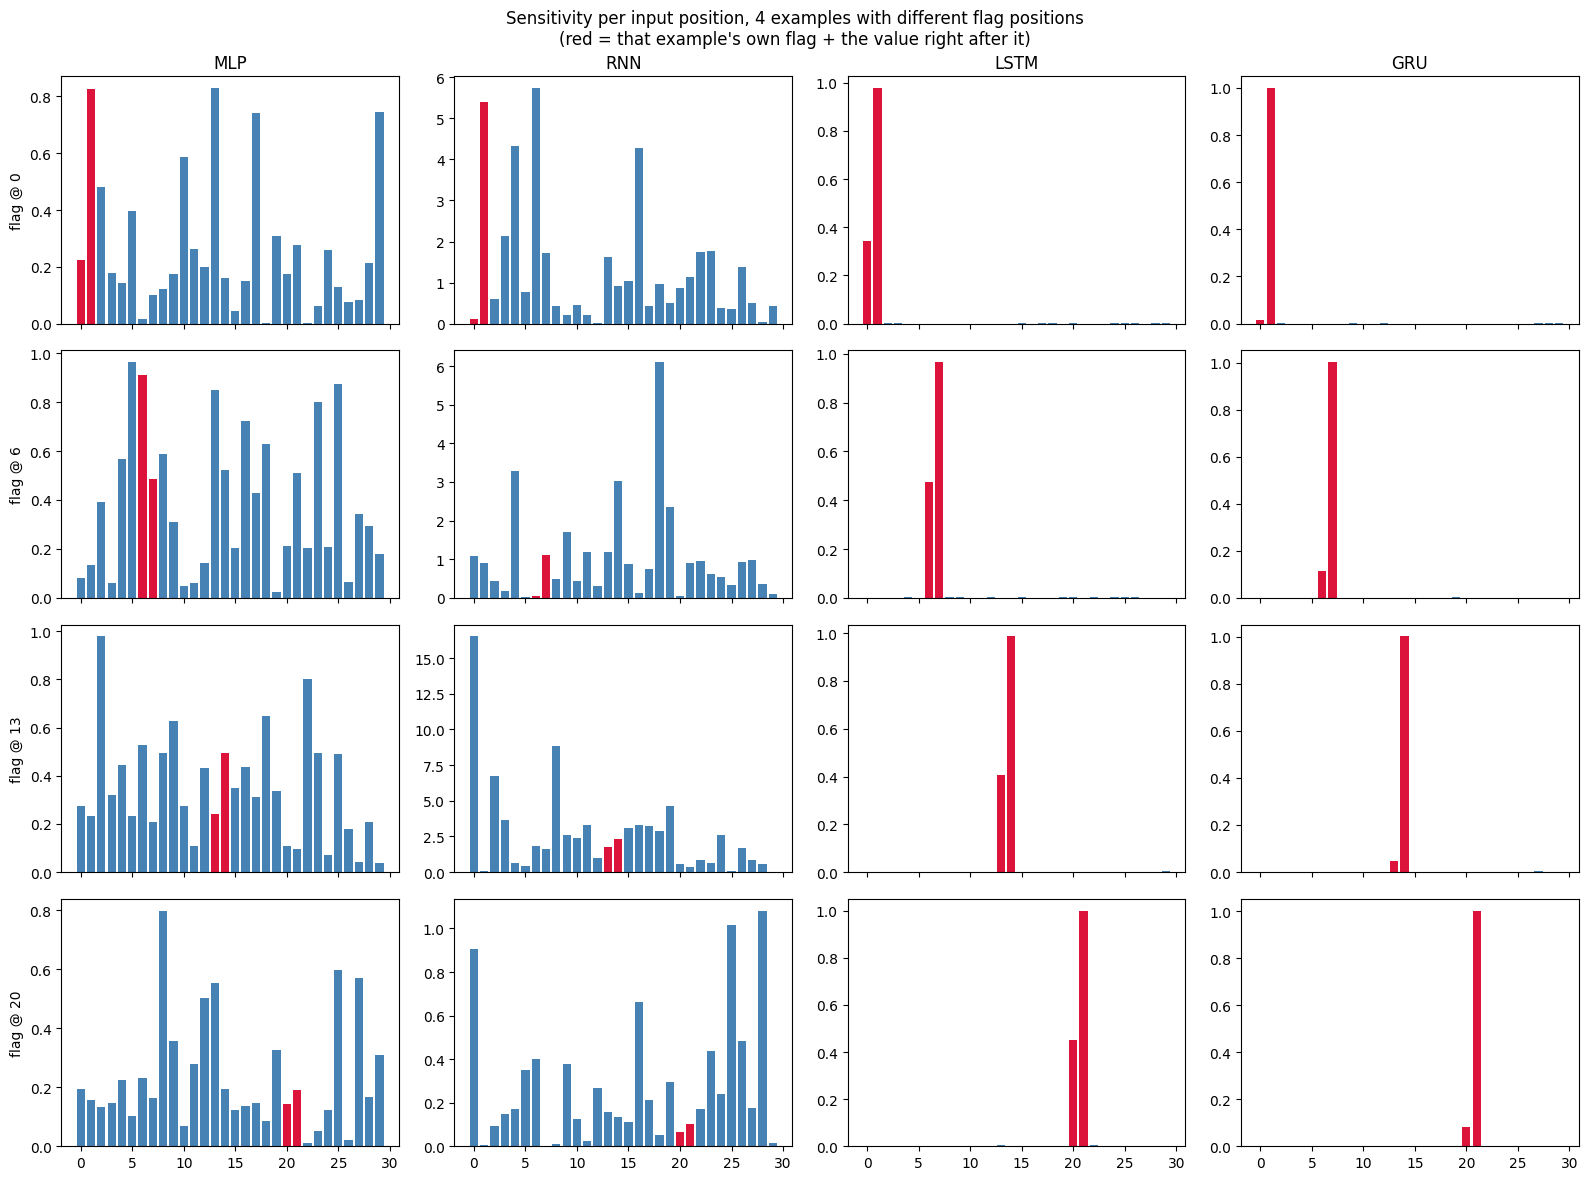

Takeaway: LSTM and GRU's sensitivity tracks each example's OWN flag position -- wherever it
happens to be -- concentrating on the flag and the value right after it, and staying low
everywhere else. That's the concrete answer to 'does the state know where the flag is': yes,
dynamically, using the same shared rule at every position. MLP and RNN show no such tracking --
their sensitivity doesn't consistently follow the flag from example to example, because
neither ever learned a position-independent version of the rule.


In [21]:
def input_sensitivity_single(model_fn, x_single):
    x = x_single.clone().requires_grad_(True)
    y_hat = model_fn(x.unsqueeze(0))
    grad = torch.autograd.grad(y_hat.sum(), x)[0]
    return grad.abs().reshape(-1).detach().numpy()


# 4 test examples spanning a wide range of (different!) flag positions
order = np.argsort(pos_test)
example_idxs = [order[0], order[len(order) // 3], order[2 * len(order) // 3], order[-1]]

model_fns = {
    "MLP": lambda x: mlp_seq(x.reshape(1, -1) if x.dim() == 1 else x.squeeze(-1)),
    "RNN": models_seq["RNN"],
    "LSTM": models_seq["LSTM"],
    "GRU": models_seq["GRU"],
}

fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True)
for row, idx in enumerate(example_idxs):
    true_flag_pos = int(pos_test[idx])
    x_single = X_seq_test[idx]
    for col, (name, fn) in enumerate(model_fns.items()):
        sens = input_sensitivity_single(fn, x_single)
        colors = ["crimson" if t in (true_flag_pos, true_flag_pos + 1) else "steelblue" for t in range(30)]
        axes[row, col].bar(range(30), sens, color=colors)
        if row == 0:
            axes[row, col].set_title(name)
        if col == 0:
            axes[row, col].set_ylabel(f"flag @ {true_flag_pos}")
plt.suptitle("Sensitivity per input position, 4 examples with different flag positions\n(red = that example's own flag + the value right after it)")
plt.tight_layout()
plt.show()

print("Takeaway: LSTM and GRU's sensitivity tracks each example's OWN flag position -- wherever it")
print("happens to be -- concentrating on the flag and the value right after it, and staying low")
print("everywhere else. That's the concrete answer to 'does the state know where the flag is': yes,")
print("dynamically, using the same shared rule at every position. MLP and RNN show no such tracking --")
print("their sensitivity doesn't consistently follow the flag from example to example, because")
print("neither ever learned a position-independent version of the rule.")


## 8. Transformers: a trained, interpretable self-attention example

Self-attention lets every position in a sequence directly look at every other position — no
step-by-step bottleneck like an RNN. To make the mechanism concrete (not just an equation), we
train a real `nn.TransformerEncoderLayer` (genuine multi-head self-attention + feed-forward, the
actual building block of BERT/GPT-style models) on a task where we can verify *exactly* what it
should be attending to: **given a sequence of numbers, find the position of the largest one.**

Each position outputs one logit (via a shared linear head on top of the encoder), and we train
those `seq_len` logits as a classification over "which position is the max" — a pointer-style use
of a Transformer encoder. Because finding the max doesn't depend on order, we deliberately skip
positional encoding here (it's normally added when order *does* matter, e.g. for language).


In [22]:
class TinyTransformer(nn.Module):
    def __init__(self, embed_dim=16, n_heads=2):
        super().__init__()
        self.input_proj = nn.Linear(1, embed_dim)
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=32, batch_first=True
        )
        self.out_proj = nn.Linear(embed_dim, 1)

    def forward(self, x):
        h = self.input_proj(x)  # (batch, seq_len, embed_dim)
        h = self.encoder_layer(h)  # self-attention + FFN, still (batch, seq_len, embed_dim)
        return self.out_proj(h).squeeze(-1)  # (batch, seq_len) -> one logit per position

    def attention_weights(self, x):
        h = self.input_proj(x)
        _, weights = self.encoder_layer.self_attn(
            h, h, h, need_weights=True, average_attn_weights=False
        )
        return weights  # (batch, n_heads, seq_len, seq_len)


def make_find_max_dataset(seq_len=10, n_samples=3000):
    rng = np.random.RandomState(SEED)
    X = rng.uniform(-1, 1, size=(n_samples, seq_len, 1)).astype(np.float32)
    y = X[:, :, 0].argmax(axis=1)
    return torch.tensor(X), torch.tensor(y, dtype=torch.long)


X_attn, y_attn = make_find_max_dataset()
n_train_attn = 2400
X_attn_train, y_attn_train = X_attn[:n_train_attn], y_attn[:n_train_attn]
X_attn_test, y_attn_test = X_attn[n_train_attn:], y_attn[n_train_attn:]

torch.manual_seed(SEED)
attn_model = TinyTransformer()
opt = optim.Adam(attn_model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
attn_losses = []
for _ in range(300):
    opt.zero_grad()
    logits = attn_model(X_attn_train)
    loss = loss_fn(logits, y_attn_train)
    loss.backward()
    opt.step()
    attn_losses.append(loss.item())

with torch.no_grad():
    test_logits = attn_model(X_attn_test)
    test_acc = (test_logits.argmax(1) == y_attn_test).float().mean().item()
print(f"Test accuracy at finding the position of the max value (chance = 10%): {test_acc:.1%}")


Test accuracy at finding the position of the max value (chance = 10%): 96.5%


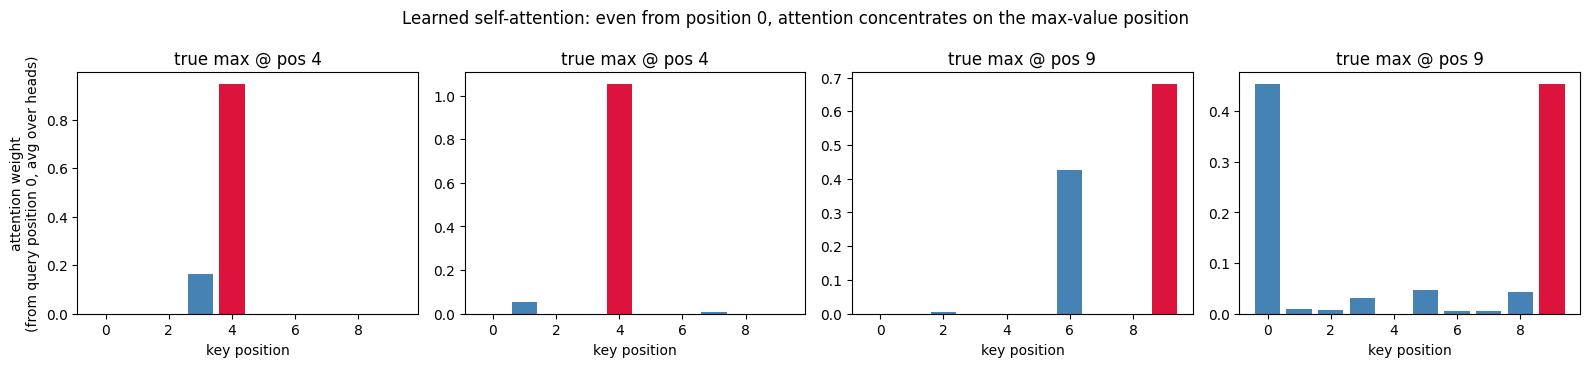

Takeaway: with random, untrained weights these bars would be ~flat (uniform 1/seq_len).
After training on the actual task, attention sharply prefers the correct position, and the
model gets 96% of held-out sequences right — the mechanism is doing real work, not decoration.


In [23]:
with torch.no_grad():
    example_x = X_attn_test[:4]
    example_weights = attn_model.attention_weights(example_x)  # (4, n_heads, seq_len, seq_len)

seq_len = example_x.shape[1]
n_heads = example_weights.shape[1]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.7))
for i, ax in enumerate(axes):
    true_idx = y_attn_test[i].item()
    # average across heads for a single, readable bar chart per example
    weights = example_weights[i].mean(dim=0)[0].numpy()  # attention *from* position 0, to all positions
    colors = ["crimson" if j == true_idx else "steelblue" for j in range(seq_len)]
    ax.bar(range(seq_len), weights, color=colors)
    ax.set_title(f"true max @ pos {true_idx}")
    ax.set_xlabel("key position")
axes[0].set_ylabel("attention weight\n(from query position 0, avg over heads)")
plt.suptitle("Learned self-attention: even from position 0, attention concentrates on the max-value position")
plt.tight_layout()
plt.show()

print("Takeaway: with random, untrained weights these bars would be ~flat (uniform 1/seq_len).")
print(f"After training on the actual task, attention sharply prefers the correct position, and the")
print(f"model gets {test_acc:.0%} of held-out sequences right — the mechanism is doing real work, not decoration.")


## 9. Autoencoders: compressing images through a bottleneck

An autoencoder learns to reconstruct its own input through a low-dimensional **bottleneck**,
forcing it to discover a compressed representation. We compress the same 8x8 digit images from §6
(64 pixels) down to just **2 numbers** and back, then look at the reconstructions and the 2D
latent space those 2 numbers form.


In [24]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=64, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 32), nn.ReLU(), nn.Linear(32, latent_dim))
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(), nn.Linear(32, input_dim), nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


torch.manual_seed(SEED)
ae = Autoencoder()
opt = optim.Adam(ae.parameters(), lr=0.01)
loss_fn = nn.MSELoss()
ae_losses = []
for _ in range(300):
    opt.zero_grad()
    recon, _ = ae(Xdig_tr)
    loss = loss_fn(recon, Xdig_tr)
    loss.backward()
    opt.step()
    ae_losses.append(loss.item())

with torch.no_grad():
    recon_test, latent_test = ae(Xdig_te)

print(f"Final reconstruction MSE: {ae_losses[-1]:.4f} (pixels scaled to [0, 1])")


Final reconstruction MSE: 0.0359 (pixels scaled to [0, 1])


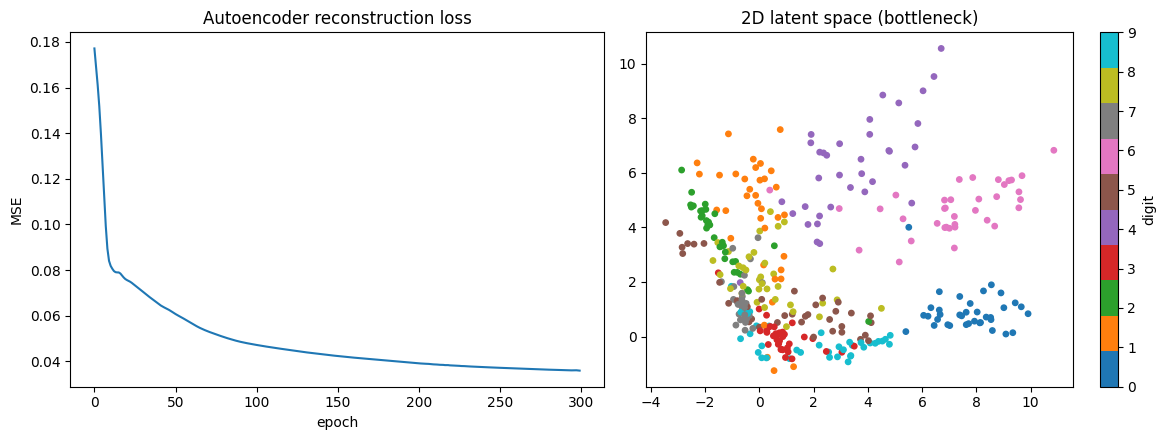

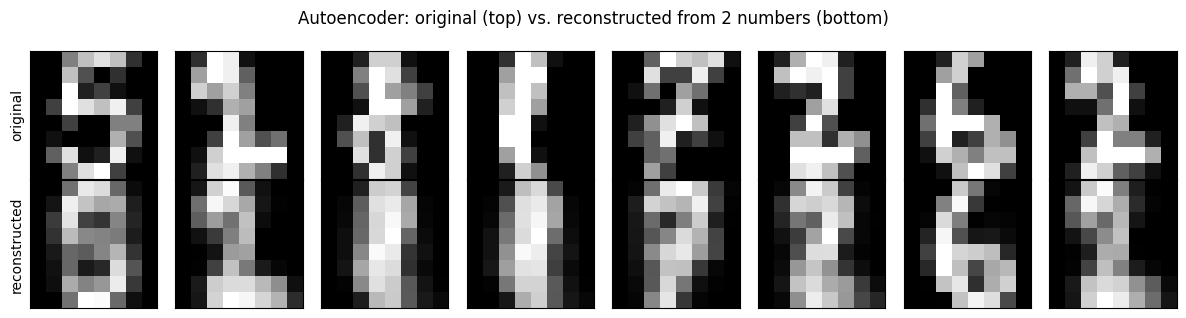

Takeaway: digits of the same class cluster together in the 2D latent space even though the
network was never given the labels — reconstruction alone forced it to organize similar
inputs similarly. §10 tests what happens if we decode a *random* point from this space.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(ae_losses)
axes[0].set_title("Autoencoder reconstruction loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")

sc = axes[1].scatter(latent_test[:, 0], latent_test[:, 1], c=y_dig_test, cmap="tab10", s=15)
plt.colorbar(sc, ax=axes[1], label="digit")
axes[1].set_title("2D latent space (bottleneck)")

plt.tight_layout()
plt.show()

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3.2))
for i in range(n_show):
    axes[0, i].imshow(X_dig_test[i].reshape(8, 8), cmap="gray")
    axes[1, i].imshow(recon_test[i].reshape(8, 8), cmap="gray")
    for r in range(2):
        axes[r, i].set_xticks([])
        axes[r, i].set_yticks([])
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("reconstructed")
plt.suptitle("Autoencoder: original (top) vs. reconstructed from 2 numbers (bottom)")
plt.tight_layout()
plt.show()

print("Takeaway: digits of the same class cluster together in the 2D latent space even though the")
print("network was never given the labels — reconstruction alone forced it to organize similar")
print("inputs similarly. §10 tests what happens if we decode a *random* point from this space.")


## 10. Variational Autoencoders: from compression to generation

A vanilla autoencoder's latent space has no constraint on its shape — it only has to be *useful
for reconstructing the training points*. A **VAE** instead forces the encoder to output a
distribution (mean + variance) per input, and adds a penalty (KL divergence) pulling that
distribution toward a standard Normal. The payoff: the *entire* latent space becomes meaningful in
a known, predictable region (`N(0, I)`), so we can sample a point without ever encoding a real
image first. We test that directly by decoding the same random points with both models — and,
since "random" is only a fair test if it's actually novel to each model, we also check *how novel*
each point really is relative to what that model saw during training.


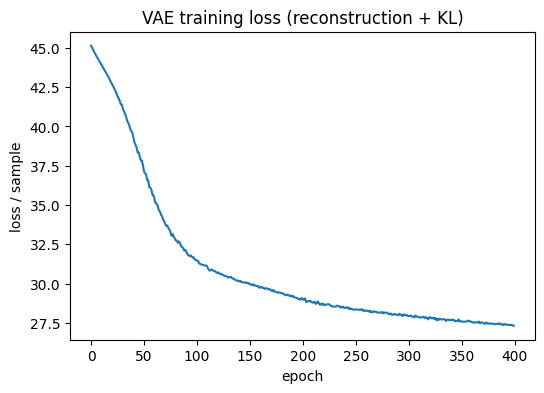

In [26]:
class VAE(nn.Module):
    def __init__(self, input_dim=64, latent_dim=2, hidden=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.fc_mu = nn.Linear(hidden, latent_dim)
        self.fc_logvar = nn.Linear(hidden, latent_dim)
        self.fc2 = nn.Linear(latent_dim, hidden)
        self.fc3 = nn.Linear(hidden, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction="sum")
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld


torch.manual_seed(SEED)
vae = VAE()
opt = optim.Adam(vae.parameters(), lr=0.001)
vae_losses = []
for _ in range(400):
    opt.zero_grad()
    recon, mu, logvar = vae(Xdig_tr)
    loss = vae_loss(recon, Xdig_tr, mu, logvar)
    loss.backward()
    opt.step()
    vae_losses.append(loss.item() / len(Xdig_tr))

plt.figure(figsize=(6, 4))
plt.plot(vae_losses)
plt.xlabel("epoch")
plt.ylabel("loss / sample")
plt.title("VAE training loss (reconstruction + KL)")
plt.show()


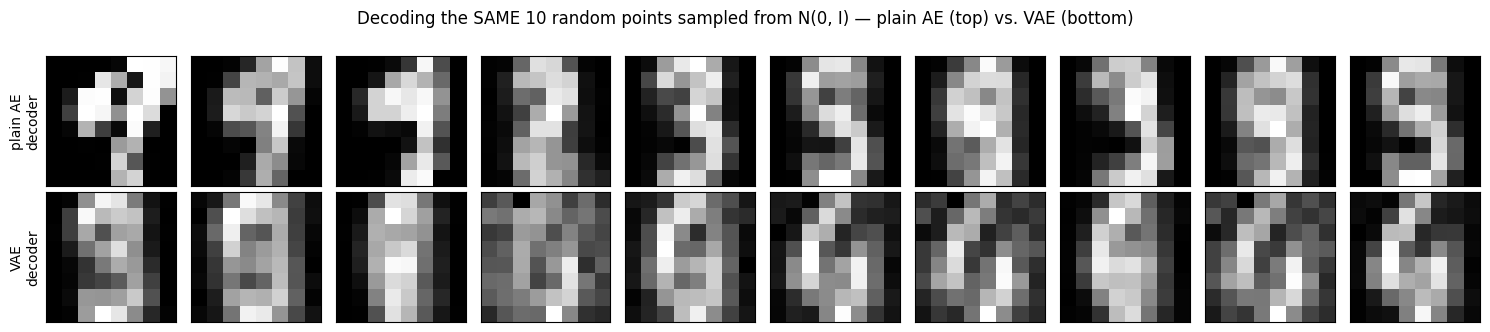

AE's real encoded digits:  mean=[2.06 2.36]  std=[3.39 2.33]
VAE's real encoded mu:     mean=[-0. -1.]  std=[1.04 0.46]

distance from each random N(0,1) point to its NEAREST real encoded digit:
  AE:  mean 0.18   [0.93 0.07 0.22 0.11 0.11 0.11 0.13 0.01 0.07 0.07]
  VAE: mean 0.52   [0.03 0.01 0.06 1.85 0.19 0.34 1.29 0.06 1.3  0.07]

decoded-image pixel contrast (std) -- lower = blurrier:
  AE mean:  0.333
  VAE mean: 0.222

Takeaway: nothing forces the AE's latent codes to sit near the origin, and here they sprawl
out with a mean nowhere near zero. Because of that, our 'random' N(0,1) points land suspiciously
close to REAL encoded digits for the AE (mean distance 0.18) -- it isn't
really generalizing to novel latent space here, it's accidentally decoding near-memorized points,
which is why its row looks sharp. The VAE's codes are properly centered near N(0,1) -- that's
what the KL penalty is for -- so its random points are genuinely more novel (mean distance
0.52) relative to traini

In [27]:
with torch.no_grad():
    _, ae_latents_real = ae(Xdig_tr)       # where the AE actually puts real digits
    ae_mu_real, _ = vae.encode(Xdig_tr)    # where the VAE actually puts real digits (mean of q(z|x))

torch.manual_seed(0)
random_latents = torch.randn(10, 2)  # sample directly from the N(0, I) prior

with torch.no_grad():
    ae_generated = ae.decoder(random_latents)
    vae_generated = vae.decode(random_latents)

fig, axes = plt.subplots(2, 10, figsize=(15, 3.4))
for i in range(10):
    axes[0, i].imshow(ae_generated[i].reshape(8, 8), cmap="gray")
    axes[1, i].imshow(vae_generated[i].reshape(8, 8), cmap="gray")
    for r in range(2):
        axes[r, i].set_xticks([])
        axes[r, i].set_yticks([])
axes[0, 0].set_ylabel("plain AE\ndecoder")
axes[1, 0].set_ylabel("VAE\ndecoder")
plt.suptitle("Decoding the SAME 10 random points sampled from N(0, I) — plain AE (top) vs. VAE (bottom)")
plt.tight_layout()
plt.show()

# is "random" actually novel, relative to where each model puts real data? and how blurry is each row?
ae_dist_to_real = torch.cdist(random_latents, ae_latents_real).min(dim=1).values
vae_dist_to_real = torch.cdist(random_latents, ae_mu_real).min(dim=1).values
ae_contrast = ae_generated.std(dim=1).numpy()   # pixel std per image -- lower means blurrier/flatter
vae_contrast = vae_generated.std(dim=1).numpy()

print(f"AE's real encoded digits:  mean={ae_latents_real.mean(dim=0).numpy().round(2)}  std={ae_latents_real.std(dim=0).numpy().round(2)}")
print(f"VAE's real encoded mu:     mean={ae_mu_real.mean(dim=0).numpy().round(2)}  std={ae_mu_real.std(dim=0).numpy().round(2)}")
print(f"\ndistance from each random N(0,1) point to its NEAREST real encoded digit:")
print(f"  AE:  mean {ae_dist_to_real.mean():.2f}   {np.round(ae_dist_to_real.numpy(), 2)}")
print(f"  VAE: mean {vae_dist_to_real.mean():.2f}   {np.round(vae_dist_to_real.numpy(), 2)}")
print(f"\ndecoded-image pixel contrast (std) -- lower = blurrier:")
print(f"  AE mean:  {ae_contrast.mean():.3f}")
print(f"  VAE mean: {vae_contrast.mean():.3f}")

print("\nTakeaway: nothing forces the AE's latent codes to sit near the origin, and here they sprawl")
print(f"out with a mean nowhere near zero. Because of that, our 'random' N(0,1) points land suspiciously")
print(f"close to REAL encoded digits for the AE (mean distance {ae_dist_to_real.mean():.2f}) -- it isn't")
print("really generalizing to novel latent space here, it's accidentally decoding near-memorized points,")
print("which is why its row looks sharp. The VAE's codes are properly centered near N(0,1) -- that's")
print(f"what the KL penalty is for -- so its random points are genuinely more novel (mean distance")
print(f"{vae_dist_to_real.mean():.2f}) relative to training, and its decoded pixel contrast is measurably")
print(f"lower ({vae_contrast.mean():.3f} vs {ae_contrast.mean():.3f}). That blur isn't a bug: reparameterization")
print("noise during training plus a pixel-wise reconstruction loss forces the VAE decoder to hedge --")
print("averaging across nearby, overlapping digit encodings instead of committing to one sharp guess.")
print("This is the well-known 'VAE blur' from the generative-modeling literature, and exactly why VAEs")
print("are often paired with adversarial or perceptual losses (as in GANs, Sec 11) when sharpness matters.")


## 11. GANs: adversarially generating the two-moons distribution

A GAN pits two networks against each other: a **generator** turns random noise into fake samples,
and a **discriminator** tries to tell those apart from real data. Both improve together. We train
one to generate points from the same two-moons distribution used in §4/§5 — a nice, visual target
because we can literally watch fake points bend from a random blob into the two crescents over
training.


In [28]:
X_real, _ = make_moons(n_samples=1000, noise=0.05, random_state=SEED)
gan_scaler = StandardScaler().fit(X_real)
X_real_t = torch.tensor(gan_scaler.transform(X_real), dtype=torch.float32)


class Generator(nn.Module):
    def __init__(self, noise_dim=8, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)


noise_dim = 8
torch.manual_seed(SEED)
G = Generator(noise_dim)
D = Discriminator()
opt_G = optim.Adam(G.parameters(), lr=2e-3, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-3, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()

n_epochs = 3000
batch_size = 128
snapshot_epochs = [0, 300, 1000, n_epochs - 1]
snapshots = {}

for epoch in range(n_epochs):
    idx = np.random.randint(0, len(X_real_t), batch_size)
    real_batch = X_real_t[idx]
    noise = torch.randn(batch_size, noise_dim)
    fake_batch = G(noise)

    opt_D.zero_grad()
    d_real = D(real_batch)
    d_fake = D(fake_batch.detach())
    d_loss = bce(d_real, torch.ones_like(d_real)) + bce(d_fake, torch.zeros_like(d_fake))
    d_loss.backward()
    opt_D.step()

    opt_G.zero_grad()
    d_fake_for_g = D(fake_batch)
    g_loss = bce(d_fake_for_g, torch.ones_like(d_fake_for_g))
    g_loss.backward()
    opt_G.step()

    if epoch in snapshot_epochs:
        with torch.no_grad():
            snapshots[epoch] = G(torch.randn(500, noise_dim)).numpy()

print(f"Final losses -> generator: {g_loss.item():.3f}  discriminator: {d_loss.item():.3f}")
print("(a stable GAN settles with the discriminator only slightly better than chance, ~log(2)=0.69 each)")


Final losses -> generator: 0.697  discriminator: 1.380
(a stable GAN settles with the discriminator only slightly better than chance, ~log(2)=0.69 each)


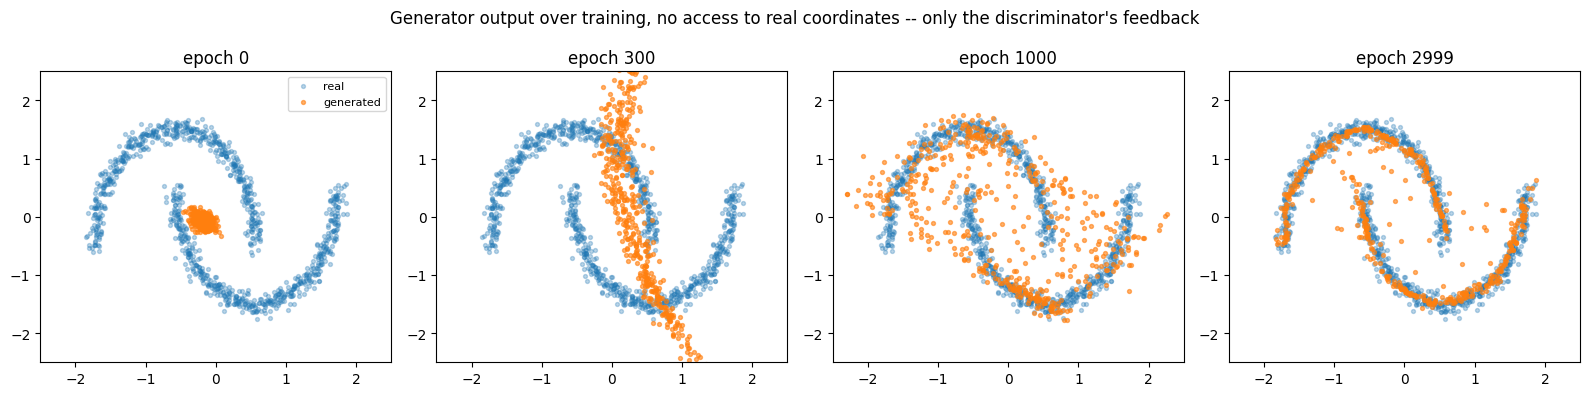

Takeaway: the generator never sees a single real (x, y) coordinate paired with its noise input --
it only ever gets a scalar 'more/less convincing' signal from the discriminator, and that alone
is enough to sculpt random noise into the two-moons shape.


In [29]:
fig, axes = plt.subplots(1, len(snapshot_epochs), figsize=(4 * len(snapshot_epochs), 4))
X_real_np = X_real_t.numpy()

for ax, epoch in zip(axes, snapshot_epochs):
    ax.scatter(X_real_np[:, 0], X_real_np[:, 1], s=8, alpha=0.3, label="real")
    ax.scatter(snapshots[epoch][:, 0], snapshots[epoch][:, 1], s=8, alpha=0.6, label="generated")
    ax.set_title(f"epoch {epoch}")
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
axes[0].legend(fontsize=8)
plt.suptitle("Generator output over training, no access to real coordinates -- only the discriminator's feedback")
plt.tight_layout()
plt.show()

print("Takeaway: the generator never sees a single real (x, y) coordinate paired with its noise input --")
print("it only ever gets a scalar 'more/less convincing' signal from the discriminator, and that alone")
print("is enough to sculpt random noise into the two-moons shape.")


## 12. Graph Neural Networks: classifying nodes from graph structure alone

A GNN generalizes convolution from a fixed grid (CNN, §6) to an arbitrary graph: each node updates
its representation by **aggregating information from its neighbors**, layer by layer. We build a
graph with 4 hidden "communities" (80 nodes total), give the model **only 12 labels total** (3 per
community — the rest are unlabeled), and give it **no node features at all**, just each node's
identity and the graph's edges. If message-passing works, information from those 12 labels should
propagate through the graph structure to correctly classify the other 68 nodes.


In [30]:
n_per_block, n_blocks = 20, 4
G_graph = nx.random_partition_graph([n_per_block] * n_blocks, p_in=0.25, p_out=0.02, seed=SEED)
block_of = np.array([G_graph.nodes[n]["block"] for n in G_graph.nodes()])
n_nodes = G_graph.number_of_nodes()

A = nx.to_numpy_array(G_graph)
A_hat = A + np.eye(n_nodes)  # add self-loops, so a node's own features survive aggregation
D_inv_sqrt = np.diag(A_hat.sum(1) ** -0.5)
A_norm = torch.tensor(D_inv_sqrt @ A_hat @ D_inv_sqrt, dtype=torch.float32)  # GCN propagation rule

X_gnn = torch.eye(n_nodes)  # featureless: only node identity, model must rely on graph structure
y_gnn = torch.tensor(block_of, dtype=torch.long)

rng3 = np.random.RandomState(SEED)
train_mask = np.zeros(n_nodes, dtype=bool)
for b in range(n_blocks):
    chosen = rng3.choice(np.where(block_of == b)[0], size=3, replace=False)
    train_mask[chosen] = True
train_mask_t = torch.tensor(train_mask)
test_mask_t = ~train_mask_t


class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, A_norm, X):
        return self.linear(A_norm @ X)  # aggregate neighbors' features, then transform


class GCN(nn.Module):
    def __init__(self, n_nodes, hidden=16, n_classes=4):
        super().__init__()
        self.gc1 = GCNLayer(n_nodes, hidden)
        self.gc2 = GCNLayer(hidden, n_classes)

    def forward(self, A_norm, X):
        h = torch.relu(self.gc1(A_norm, X))
        return self.gc2(A_norm, h)


torch.manual_seed(SEED)
gcn = GCN(n_nodes)
opt = optim.Adam(gcn.parameters(), lr=0.05, weight_decay=5e-4)
loss_fn = nn.CrossEntropyLoss()
gcn_losses = []
for _ in range(200):
    opt.zero_grad()
    logits = gcn(A_norm, X_gnn)
    loss = loss_fn(logits[train_mask_t], y_gnn[train_mask_t])
    loss.backward()
    opt.step()
    gcn_losses.append(loss.item())

with torch.no_grad():
    preds = gcn(A_norm, X_gnn).argmax(1)
test_acc = (preds[test_mask_t] == y_gnn[test_mask_t]).float().mean().item()
print(f"Labeled (training) nodes: {train_mask.sum()} / {n_nodes}")
print(f"Test accuracy on the remaining {int(test_mask_t.sum())} UNlabeled nodes: {test_acc:.1%}")


Labeled (training) nodes: 12 / 80
Test accuracy on the remaining 68 UNlabeled nodes: 94.1%


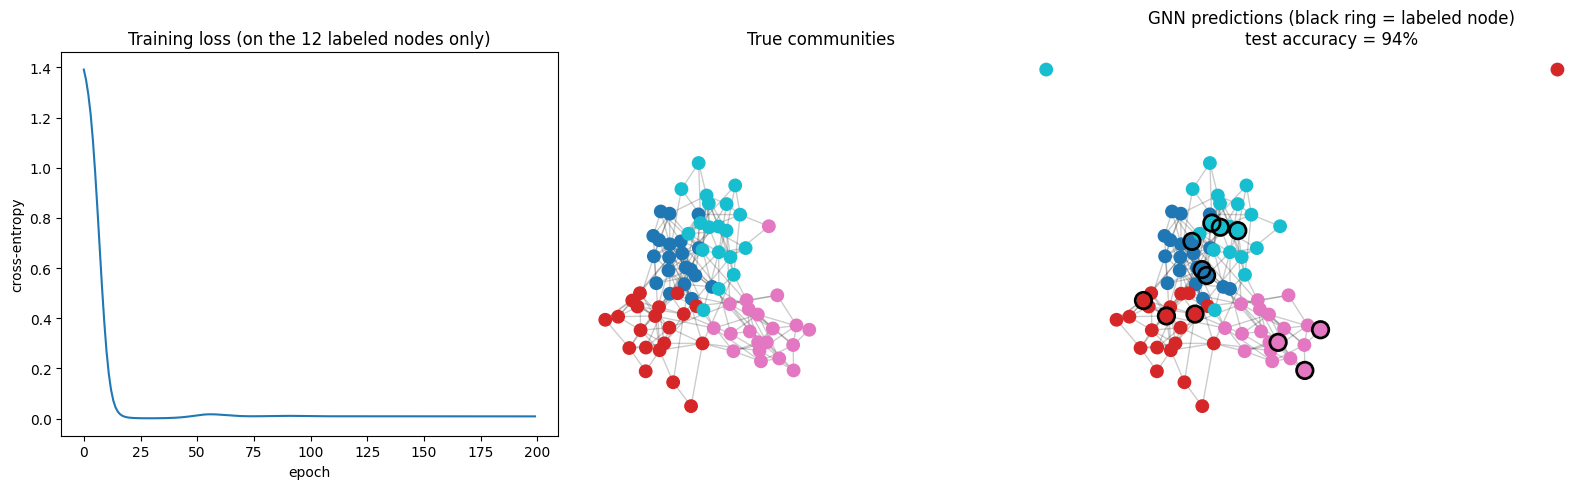

Takeaway: the model never saw a single feature describing any node, and 85% of nodes had no
label -- everything it got right came from propagating the 12 known labels through the graph's
edges via message passing, exactly the mechanism that sets GNNs apart from CNNs/MLPs.


In [31]:
pos = nx.spring_layout(G_graph, seed=SEED)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(gcn_losses)
axes[0].set_title("Training loss (on the 12 labeled nodes only)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")

nx.draw_networkx_edges(G_graph, pos, ax=axes[1], alpha=0.2)
nx.draw_networkx_nodes(G_graph, pos, ax=axes[1], node_color=block_of, cmap="tab10", node_size=80)
axes[1].set_title("True communities")
axes[1].axis("off")

nx.draw_networkx_edges(G_graph, pos, ax=axes[2], alpha=0.2)
nx.draw_networkx_nodes(G_graph, pos, ax=axes[2], node_color=preds.numpy(), cmap="tab10", node_size=80)
nx.draw_networkx_nodes(
    G_graph, pos, ax=axes[2], nodelist=list(np.where(train_mask)[0]),
    node_color="none", edgecolors="black", linewidths=2, node_size=140,
)
axes[2].set_title(f"GNN predictions (black ring = labeled node)\ntest accuracy = {test_acc:.0%}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Takeaway: the model never saw a single feature describing any node, and 85% of nodes had no")
print("label -- everything it got right came from propagating the 12 known labels through the graph's")
print("edges via message passing, exactly the mechanism that sets GNNs apart from CNNs/MLPs.")


## 13. Embeddings: categories becoming vectors

An embedding maps a discrete category (an integer ID) to a point in a continuous vector space,
learned jointly with the task. To make the effect visible, we build a synthetic classification
task where 20 categories secretly belong to 4 underlying clusters, and only the *cluster* (not the
raw category ID) determines the label. If the embedding is learning anything useful, points from
the same true cluster should end up close together — **with no cluster information ever given to
the model directly.**


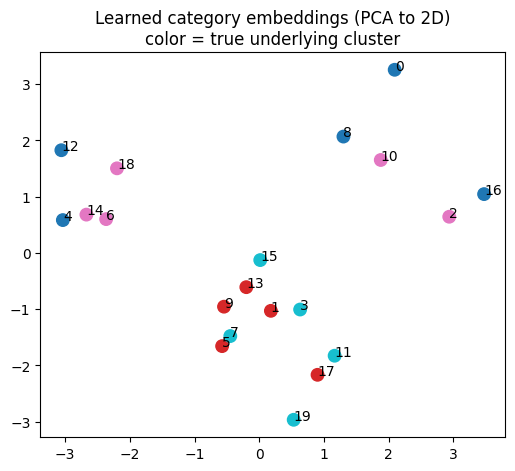

Takeaway: category IDs are arbitrary integers with no inherent notion of 'distance' -- yet
after training, categories from the same true cluster land near each other in vector space.
This is what lets 'similar' words/products/users end up with similar embeddings in practice.


In [32]:
n_categories = 20
n_clusters = 4
cluster_of = np.arange(n_categories) % n_clusters

rng2 = np.random.RandomState(SEED)
n_samples_emb = 2000
cats = rng2.randint(0, n_categories, size=n_samples_emb)
labels = (cluster_of[cats] % 2).astype(np.float32)  # label depends only on the cluster

cats_t = torch.tensor(cats, dtype=torch.long)
labels_t = torch.tensor(labels).unsqueeze(1)


class EmbeddingClassifier(nn.Module):
    def __init__(self, n_categories, embed_dim=8):
        super().__init__()
        self.embedding = nn.Embedding(n_categories, embed_dim)
        self.head = nn.Sequential(nn.Linear(embed_dim, 16), nn.ReLU(), nn.Linear(16, 1))

    def forward(self, x):
        return self.head(self.embedding(x))


torch.manual_seed(SEED)
emb_model = EmbeddingClassifier(n_categories)
opt = optim.Adam(emb_model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()
for _ in range(300):
    opt.zero_grad()
    loss = loss_fn(emb_model(cats_t), labels_t)
    loss.backward()
    opt.step()

with torch.no_grad():
    vectors = emb_model.embedding.weight.numpy()
vectors_2d = PCA(n_components=2, random_state=SEED).fit_transform(vectors)

plt.figure(figsize=(6, 5))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=cluster_of, cmap="tab10", s=80)
for i in range(n_categories):
    plt.annotate(str(i), (vectors_2d[i, 0], vectors_2d[i, 1]))
plt.title("Learned category embeddings (PCA to 2D)\ncolor = true underlying cluster")
plt.show()

print("Takeaway: category IDs are arbitrary integers with no inherent notion of 'distance' -- yet")
print("after training, categories from the same true cluster land near each other in vector space.")
print("This is what lets 'similar' words/products/users end up with similar embeddings in practice.")


## 14. Recap

| Section | Cheat sheet concept | What the takeaway showed |
|---|---|---|
| 2 | Activation functions | Sigmoid/tanh saturate → vanishing gradients; ReLU doesn't |
| 3 | Bias–variance trade-off | Underfit / good fit / overfit, quantified via the train–test error gap |
| 4 | Batch vs. online learning | Retraining from scratch vs. incremental updates, both fix a frozen model's drift-decay |
| 5 | Feedforward NN (FNN/MLP) | Deep net fits train data better but overfits this simple dataset -- test accuracy drops |
| 6 | Convolutional NN (CNN) | Small reused filters (vs. MLP's per-pixel weights) keep more accuracy under pixel shifts |
| 7 | RNN / LSTM / GRU | With the signal's position randomized, MLP and RNN both fail (worse than baseline); LSTM/GRU solve it via weight-sharing-across-time + gating |
| 8 | Transformers (self-attention) | Trained attention weights concentrate on the provably-correct position |
| 9 | Autoencoders | 64 pixels compressed to 2 numbers and reconstructed |
| 10 | Variational autoencoders | VAE's codes are genuinely centered at N(0,1) (AE's aren't) -- but that honesty costs it sharpness (blur) |
| 11 | GANs | Adversarial feedback alone sculpts noise into the two-moons shape |
| 12 | Graph Neural Networks | 12 labels propagate through graph structure to classify 68 unlabeled nodes |
| 13 | Embeddings | Category → vector; same true cluster ended up close in space |

See [`ReadMe.md`](ReadMe.md) for the conceptual map this notebook implements.
